# Visualization and further exploration

In this notebook, we seek to understand the behaviour of two solar power plants through the data generated by the photovoltaic modules. To do so, we will talk about:

1. **Reminder on photovoltaic systems or PV systems**
2. **EDA on:**
    - ***DC and AC power***
    - ***Irradiation***
    - ***ambient and module temperature***
    - ***yield***
3. **Correlation of all features**
4. **Comparison of two power plants** 

## Reminder on PV systems

<center>
<img src="https://upload.wikimedia.org/wikipedia/commons/a/a0/From_a_solar_cell_to_a_PV_system.svg" width="450"><br/>
</center>


**``PV system``** is a power system designed to supply usable solar power by means of photovoltaics.


**``PV Cell``** is an electrical device that converts the energy of light directly into electricity by the photovoltaic effect, which is a physical and chemical phenomenon. It is also the basics photovoltaic device that is the building block PV modules.

**``Photovoltaic effect``**  is the generation of voltage and electric current in a material upon exposure to light.

**``PV module``** is a group of PV cell connected in serie and/or parallel and encapsulated in an environmentally protective laminate.

**``PV panel``** is a group of modules that is the basic building block of a PV array.

**``PV array``** is a group of panels that comprises the complete PV generating unit.

### PV inverter

<center>
<img src="https://www.futuregenerationenergy.ie/wp-content/uploads/2017/03/santnu_new.jpg" width="450"><br/>
</center>

**``PV inverter``** convert battery or PV array DC power to AC power for use with conventional utility-powered appliances. It is heart of PV systems because PV array is a DC source, an inverter is required to convert the dc power to normal ac power that is used in our homes and offices.

PV systems are very influenced by weather condition, if the weather is good, we get a maximun yield but if the weather is bad, we get a minimun yield. That is why there is important to know how weather condition can impact on yield of the two solar power plants.

**Source**
- [Photovoltaic(PV) Tutorial](http://web.mit.edu/taalebi/www/scitech/pvtutorial.pdf)

- [PV Inverter](https://www.futuregenerationenergy.ie/domestic/solar-pv-inverters/)

- [PV Systems](https://en.wikipedia.org/wiki/Photovoltaic_system)


According to the notion of PV systems, the important feature are:

- *DC power*

- *AC power*

- *Yield*

- *ambiant Temperature*

- *module temperature*

- *irradiation*

Okay, let's go to the next section.

In [1]:
#!pip install pandas-profiling
!pip install fg-data-profiling

  Using cached joblib-1.1.1-py2.py3-none-any.whl.metadata (5.2 kB)
Using cached joblib-1.1.1-py2.py3-none-any.whl (309 kB)
  Attempting uninstall: joblib
    Found existing installation: joblib 1.4.2
    Uninstalling joblib-1.4.2:
      Successfully uninstalled joblib-1.4.2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-learn 1.7.2 requires joblib>=1.2.0, but you have joblib 1.1.1 which is incompatible.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [5]:
import data_profiling

In [ ]:
!pip install holoviews
!pip install cufflinks

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
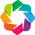

In [29]:
#import all package needed
import matplotlib
#matplotlib.use('TkAgg') # Or use 'QtAgg'
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import normaltest
import holoviews as hv
from holoviews import opts
import cufflinks as cf
hv.extension('bokeh')

In [ ]:
!pip install --upgrade plotly

In [10]:
cf.set_config_file(offline = True)
sns.set(style="whitegrid")

## Plant I: Solar Power Generation data

Plant contains 22 inverters where each inverter are connected with several PV array. Every 15 min, each inverter records his data. So, if we want to know how many the plant has produced a power in a hour, we just compute the contribution of 22 inverters. 

In [11]:
#we take file for plant 1 Generation data
file = 'Plant_1_Generation_Data.csv'

In [12]:
plant1_data = pd.read_csv(file) # load data

In [13]:
profile = ProfileReport(plant1_data)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:01<00:00,  4.46it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [14]:
plant1_data.tail()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
68773,17-06-2020 23:45,4135001,uHbuxQJl8lW7ozc,0.0,0.0,5967.000,7287002.0
68774,17-06-2020 23:45,4135001,wCURE6d3bPkepu2,0.0,0.0,5147.625,7028601.0
68775,17-06-2020 23:45,4135001,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000,7251204.0
68776,17-06-2020 23:45,4135001,zBIq5rxdHJRwDNY,0.0,0.0,5817.000,6583369.0
68777,17-06-2020 23:45,4135001,zVJPv84UY57bAof,0.0,0.0,5910.000,7363272.0


In [15]:
print('The number of inverter for data_time {} is {}'.format('15-05-2020 23:00', plant1_data[plant1_data.DATE_TIME == '15-05-2020 23:00']['SOURCE_KEY'].nunique()))

The number of inverter for data_time 15-05-2020 23:00 is 22


In [16]:
plant1_data.info() # we check if there exist missing value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.7+ MB


In [17]:
#we compute a sum of 22 inverters
plant1_data = plant1_data.groupby('DATE_TIME')[['DC_POWER','AC_POWER', 'DAILY_YIELD','TOTAL_YIELD']].agg('sum')

In [18]:
plant1_data = plant1_data.reset_index()

In [19]:
plant1_data.head()

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,01-06-2020 00:00,0.0,0.0,5407.25,153519480.0
1,01-06-2020 00:15,0.0,0.0,0.00,153519480.0
2,01-06-2020 00:30,0.0,0.0,0.00,153519480.0
3,01-06-2020 00:45,0.0,0.0,0.00,153519480.0
4,01-06-2020 01:00,0.0,0.0,0.00,153519480.0


**``Cleaning data``**

I convert ``DATE_TIME`` object type to datetime type. After I separate ``DATE_TIME`` to **date** and **time**

In [20]:
plant1_data['DATE_TIME'] = pd.to_datetime(plant1_data['DATE_TIME'], errors='coerce')

In [21]:
plant1_data['time'] = plant1_data['DATE_TIME'].dt.time
plant1_data['date'] = pd.to_datetime(plant1_data['DATE_TIME'].dt.date)

In [22]:
plant1_data.shape # our data reduced very well

(3158, 7)

In [23]:
#we check
plant1_data.head()

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,time,date
0,2020-01-06 00:00:00,0.0,0.0,5407.25,153519480.0,00:00:00,2020-01-06
1,2020-01-06 00:15:00,0.0,0.0,0.00,153519480.0,00:15:00,2020-01-06
2,2020-01-06 00:30:00,0.0,0.0,0.00,153519480.0,00:30:00,2020-01-06
3,2020-01-06 00:45:00,0.0,0.0,0.00,153519480.0,00:45:00,2020-01-06
4,2020-01-06 01:00:00,0.0,0.0,0.00,153519480.0,01:00:00,2020-01-06


In [24]:
plant1_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE_TIME    1152 non-null   datetime64[ns]
 1   DC_POWER     3158 non-null   float64       
 2   AC_POWER     3158 non-null   float64       
 3   DAILY_YIELD  3158 non-null   float64       
 4   TOTAL_YIELD  3158 non-null   float64       
 5   time         1152 non-null   object        
 6   date         1152 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(4), object(1)
memory usage: 172.8+ KB


### EDA for ``DC power``, ``AC power`` and ``Yield``.

Here, we use

1. Line or scatter plot

2. change rate.

3. Box and Whisker plot

4. calendar plot

5. Bar chart.

## **``DC Power``**

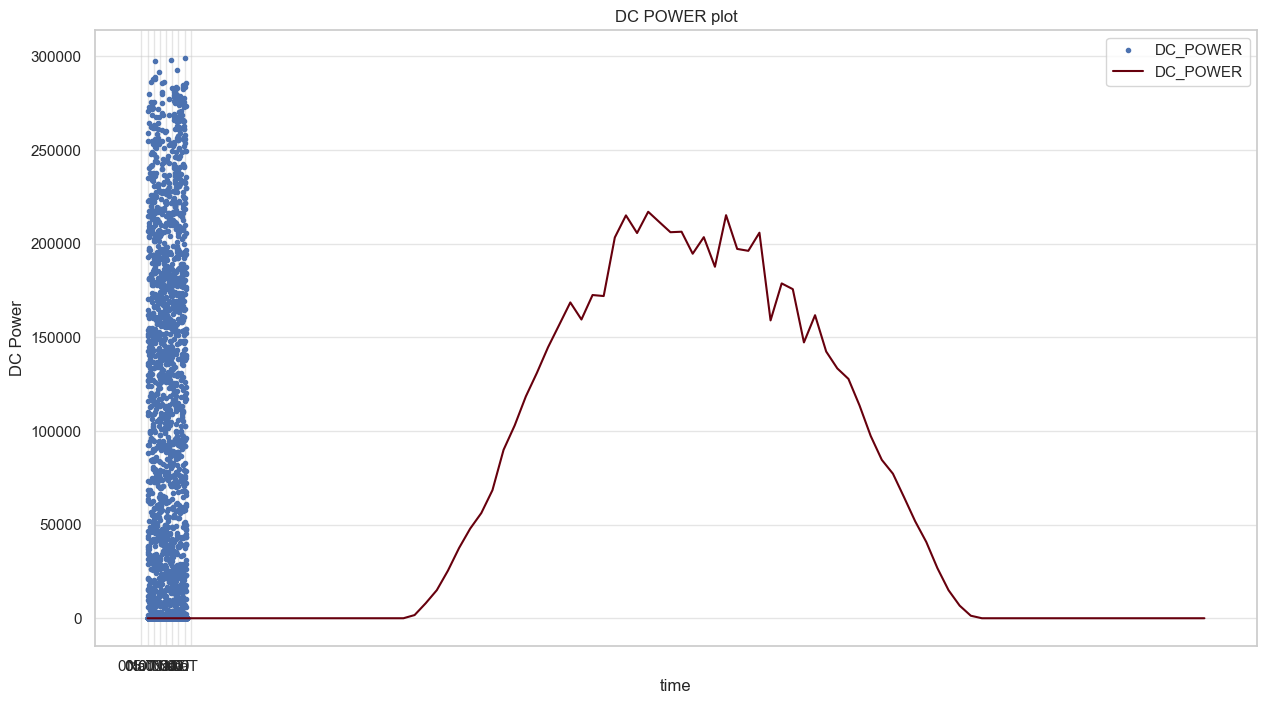

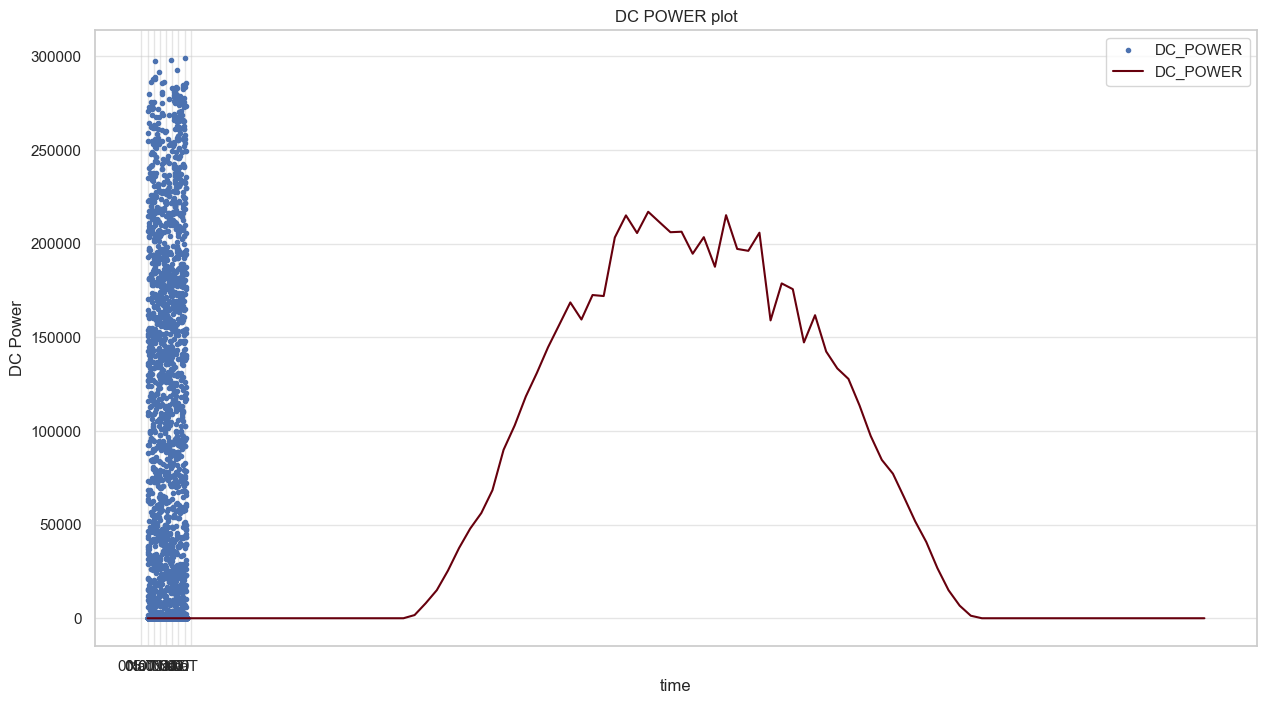

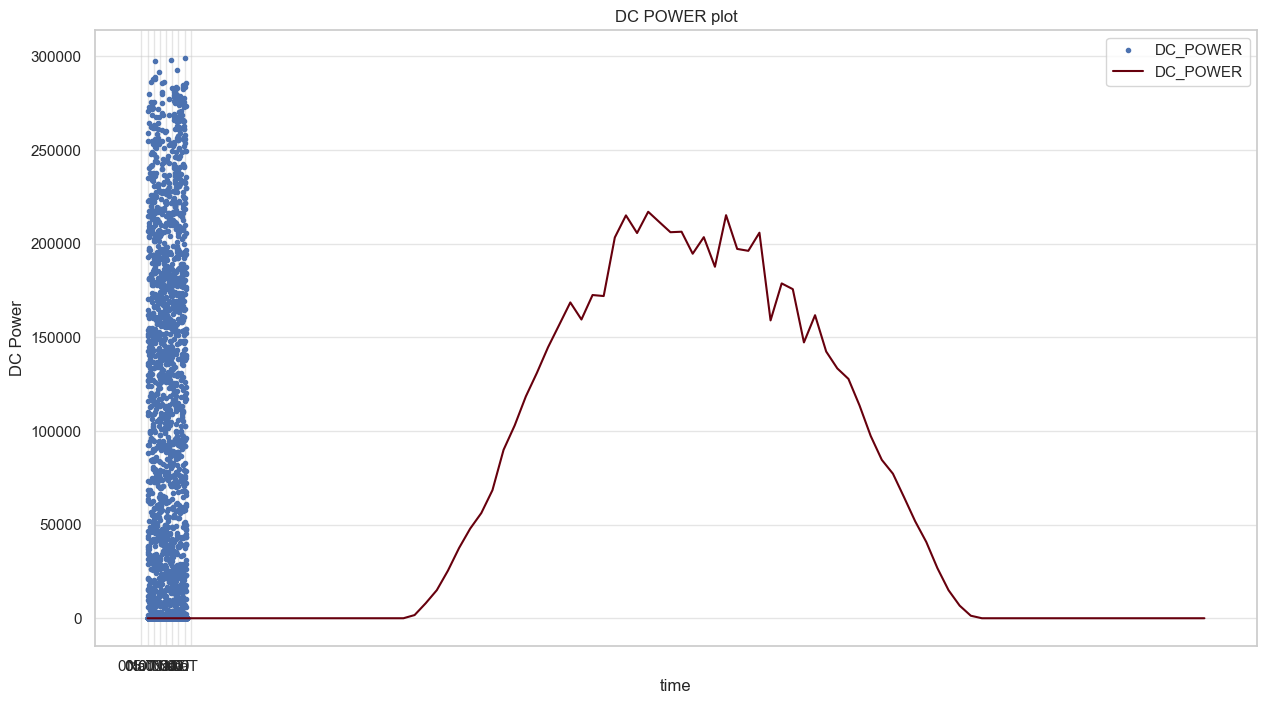

In [30]:
#plant1_data.iplot(x= 'time', y='DC_POWER', xTitle='Time',  yTitle= 'DC Power', title='DC POWER plot')
plant1_data.plot(x= 'time', y='DC_POWER', style='.', figsize = (15, 8))
plant1_data.groupby('time')['DC_POWER'].agg('mean').plot(legend=True, colormap='Reds_r')
plt.ylabel('DC Power')
plt.title('DC POWER plot')
plt.show()

Between 05:33:20 and 18:00:00, the Plant produces a dc power but otherwise there is null. The reason is sunlight. 

In [33]:
#Okay, we are going to see dc power in each day produced by Plant.
#we create calendar_dc data how in each day Plant produce a dc power in each time.

calendar_dc = plant1_data.pivot_table(values='DC_POWER', index='time', columns='date')

In [34]:
calendar_dc.tail()

date,2020-01-06,2020-02-06,2020-03-06,2020-04-06,2020-05-06,2020-06-06,2020-07-06,2020-08-06,2020-09-06,2020-10-06,2020-11-06,2020-12-06
time,,,,,,,,,,,,
22:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [35]:
# define function to multi plot

def multi_plot(data= None, row = None, col = None, title='DC Power'):
    cols = data.columns # take all column
    gp = plt.figure(figsize=(20,20)) 
    
    gp.subplots_adjust(wspace=0.2, hspace=0.8)
    for i in range(1, len(cols)+1):
        ax = gp.add_subplot(row,col, i)
        data[cols[i-1]].plot(ax=ax, style = 'k.')
        ax.set_title('{} {}'.format(title, cols[i-1]))

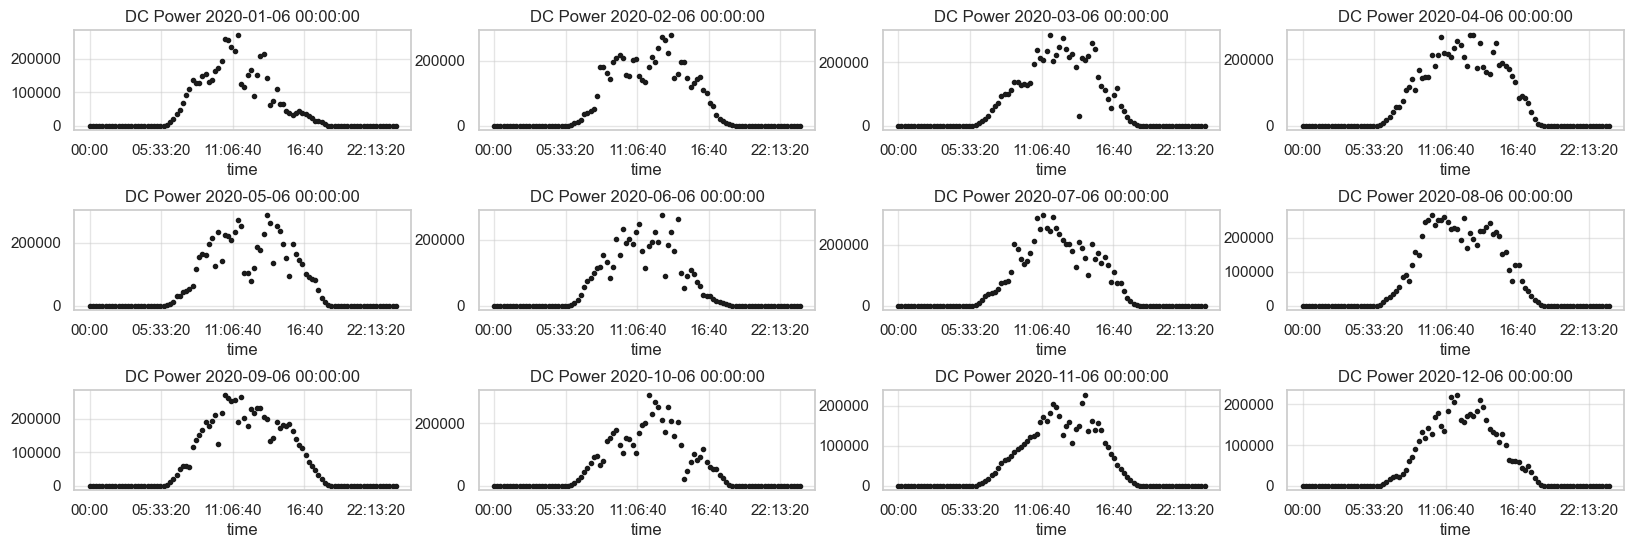

In [36]:
multi_plot(data=calendar_dc, row=9, col=4)

Almost all the curves are the same despite some fluctuation between 11 am and 2 pm. except the curve of May 20 and 25 which gives a uniform shape.

In [37]:
daily_dc = plant1_data.groupby('date')['DC_POWER'].agg('sum')

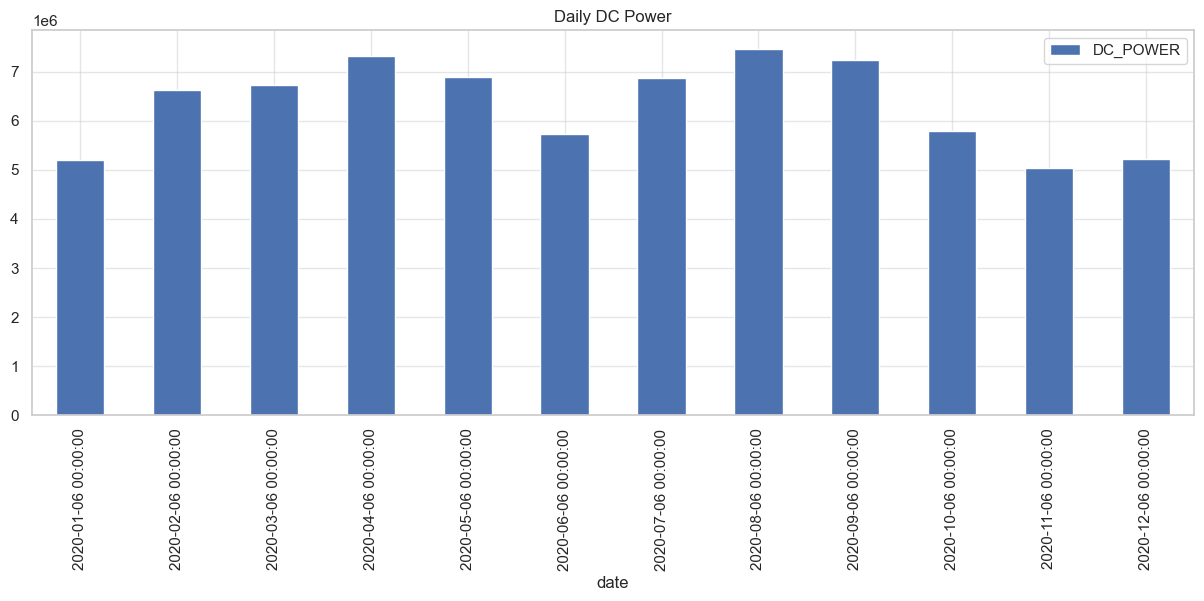

In [38]:
daily_dc.plot.bar(figsize=(15,5), legend=True)
plt.title('Daily DC Power')
plt.show()

Only **``2020-05-25``** dc power is maximun.

## **``Daily Yield``**

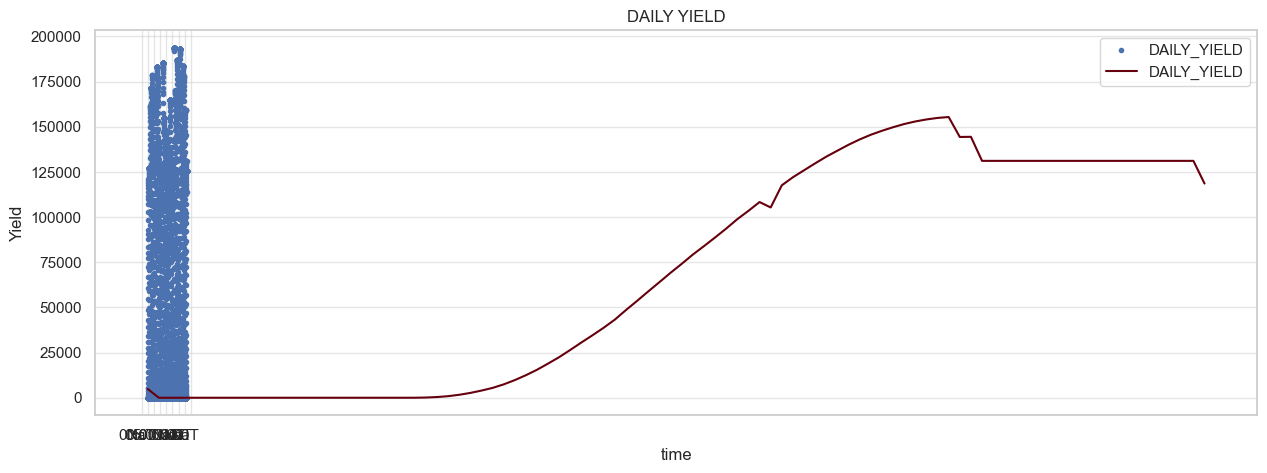

In [39]:
plant1_data.plot(x='time', y='DAILY_YIELD', style='b.', figsize=(15,5))
plant1_data.groupby('time')['DAILY_YIELD'].agg('mean').plot(legend=True, colormap='Reds_r')
plt.title('DAILY YIELD')
plt.ylabel('Yield')
plt.show()

data gives us a logistics-like function but after ``18:00`` the energy decrease slowly; suddenly at ``00:00`` breakdown.

In [40]:
#pivot table data
daily_yield = plant1_data.pivot_table(values='DAILY_YIELD', index='time', columns='date')

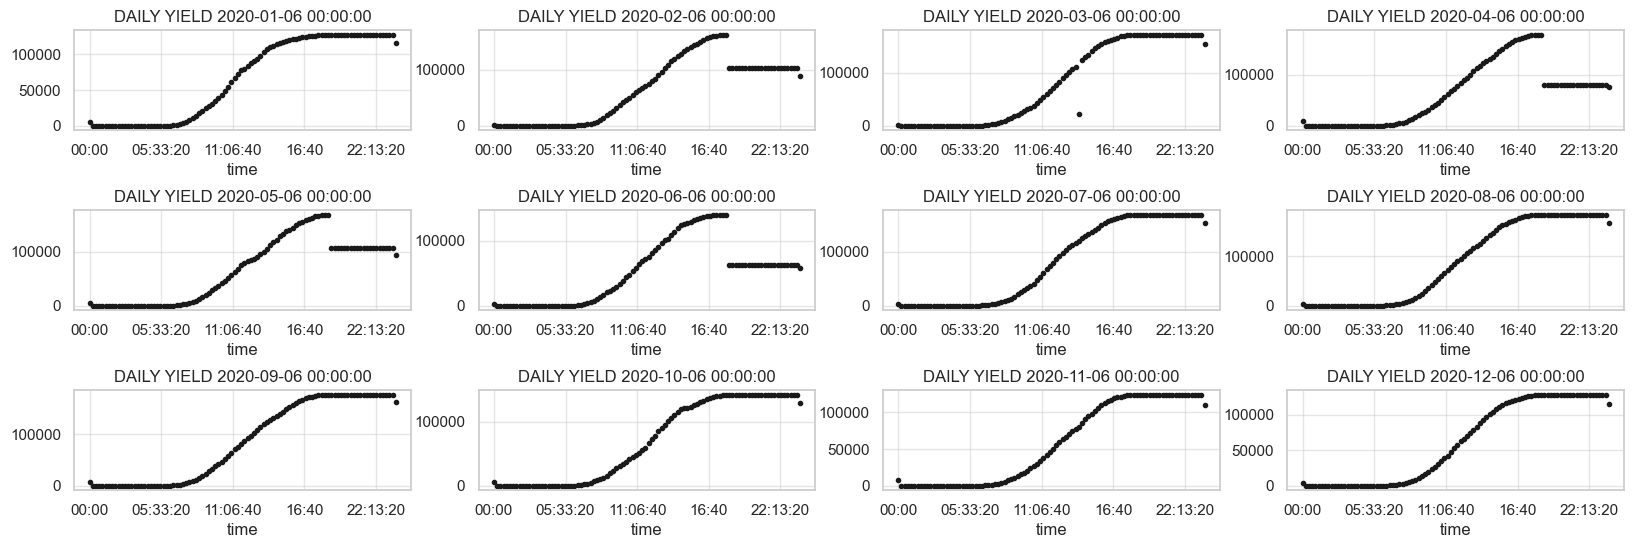

In [41]:
# we plot all daily yield
multi_plot(data=daily_yield.interpolate(), row=9, col=4, title='DAILY YIELD')

As we can see some daily_yield date (``2020-02-06``, ``2020-05-19``,...) have a logistic shape  with missing values but others have not.

Every 15 min data is recorded. After 15 min, we get a **new yield**. To compute this new yield it is just this formula:

``new yield = next yield - previous yield``. It is a difference equation that ``.diff()`` pandas function can help us to compute it.

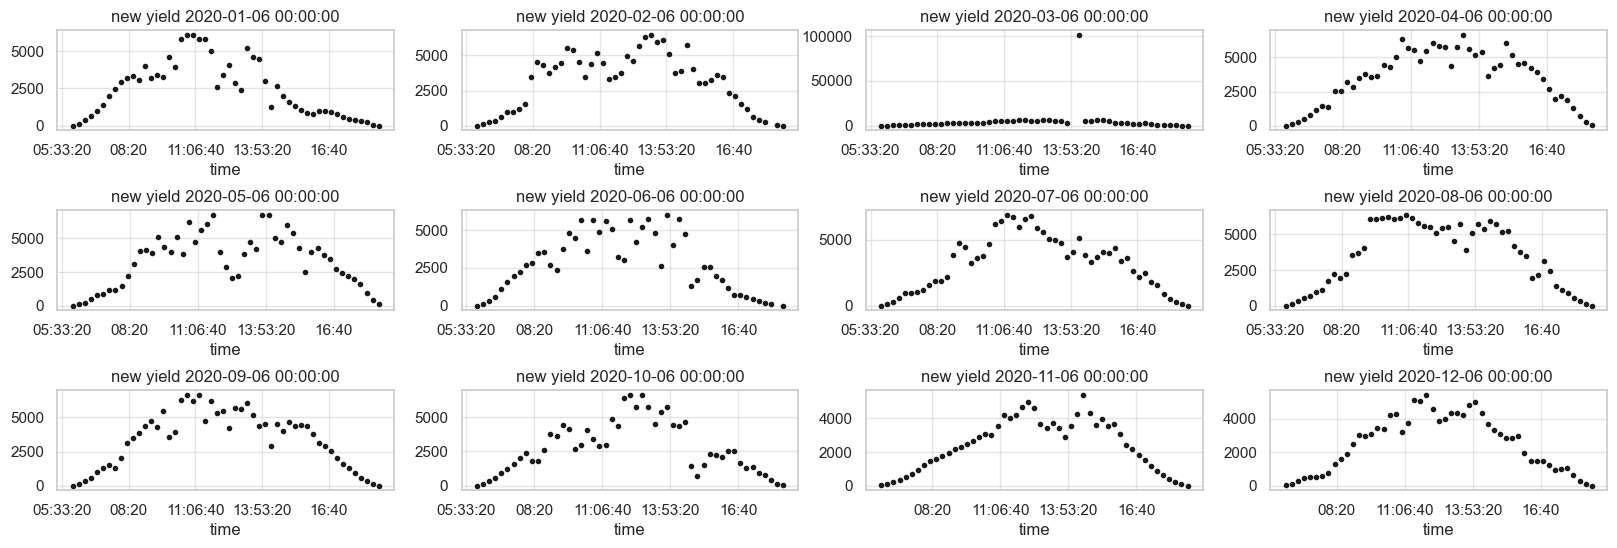

In [42]:
#plotting a change rate daily yield over time
multi_plot(data=daily_yield.diff()[daily_yield.diff()>0], row=9, col=4, title='new yield')

Between ``08:20`` and ``16:40``, we obtain each 15min, **$new yield > 2500$** with fluctuation.

**Daily Yield each day**

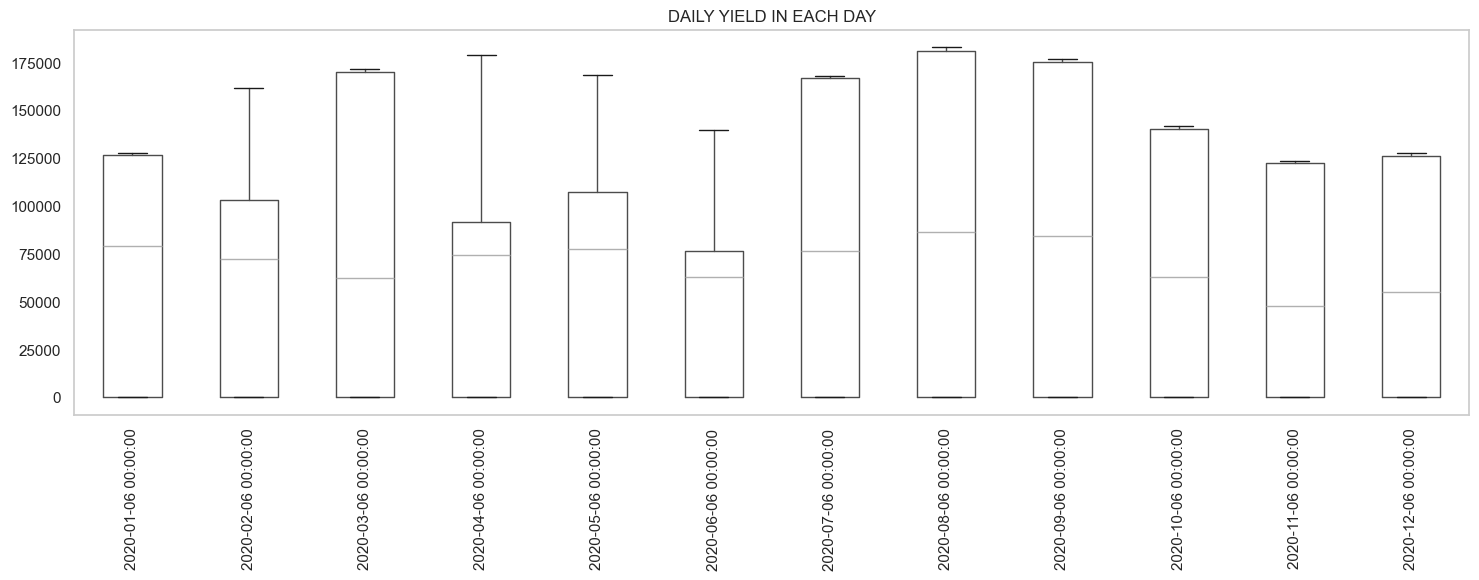

In [43]:
daily_yield.boxplot(figsize=(18,5), rot=90, grid=False)
plt.title('DAILY YIELD IN EACH DAY')
plt.show()

For each day, the daily yield change. some day is high. The observation of all boxes is good, outlier does not exist. 

For further details see
Wikipedia's entry for [``boxplot``](<https://en.wikipedia.org/wiki/Box_plot>).

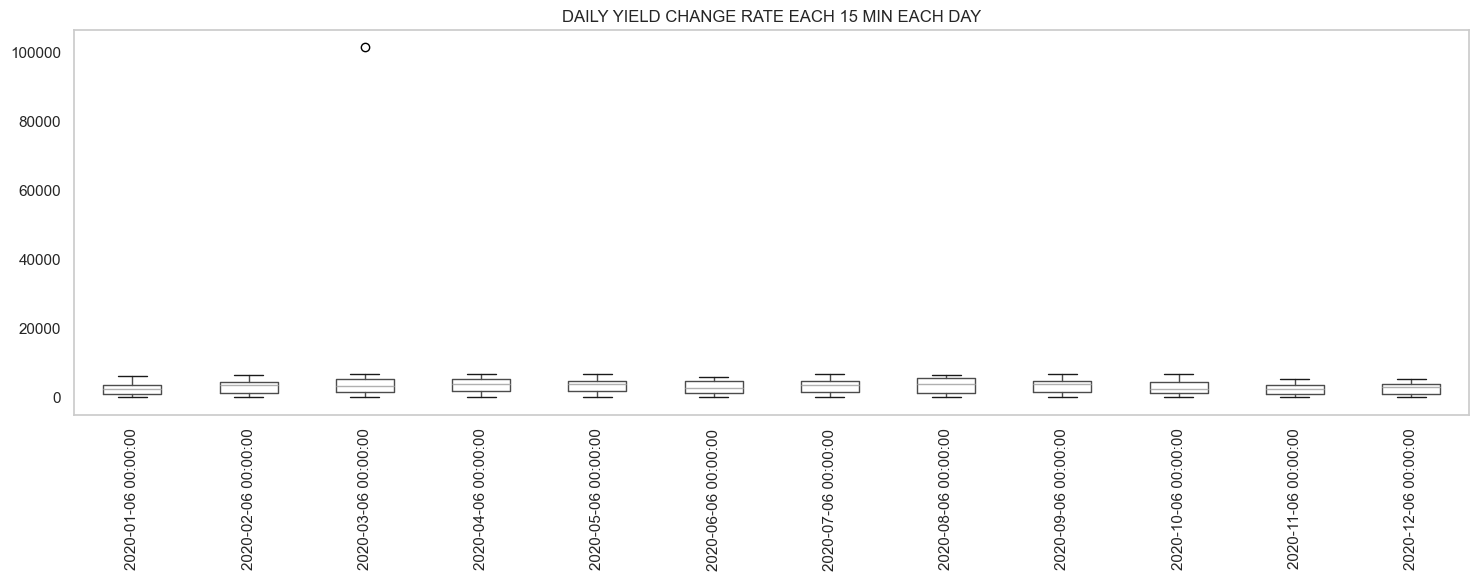

In [44]:
daily_yield.diff()[daily_yield.diff()>0].boxplot(figsize=(18,5), rot=90, grid=False)
plt.title('DAILY YIELD CHANGE RATE EACH 15 MIN EACH DAY')
plt.show()

Only two days have an outlier **2020-03-06** and **2020-05-21**. 

In [45]:
#we compute a daily yield for each date.
dyield = plant1_data.groupby('date')['DAILY_YIELD'].agg('sum')

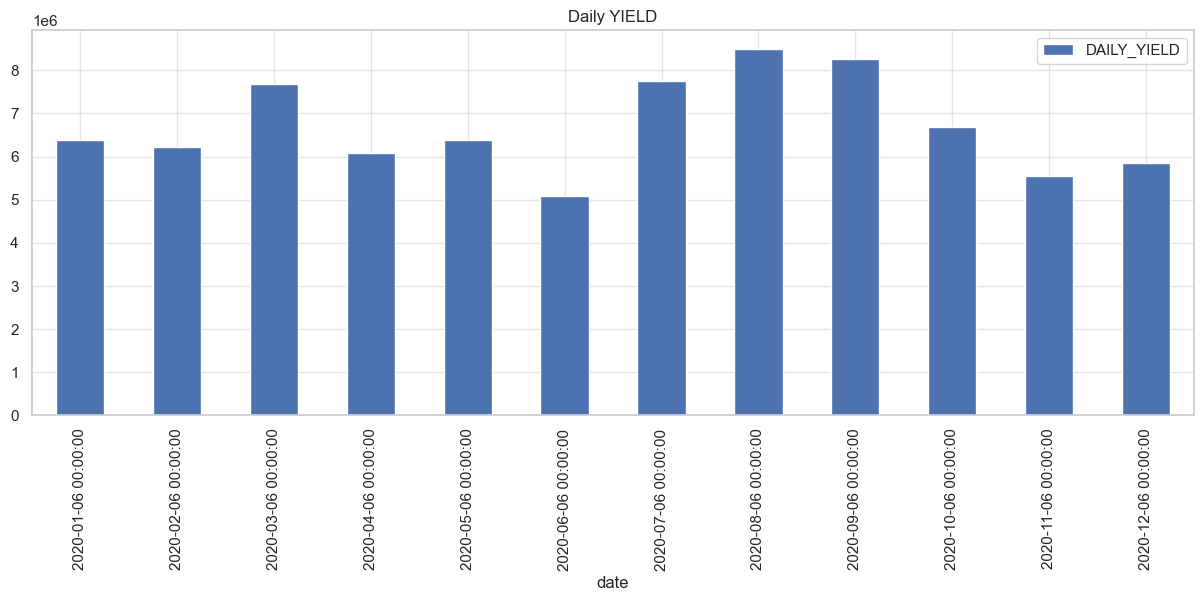

In [46]:
dyield.plot.bar(figsize=(15,5), legend=True)
plt.title('Daily YIELD')
plt.show()

## Plant_1: Weather Sensor Data

In [47]:
file1 = 'Plant_1_Weather_Sensor_Data.csv'

In [48]:
plant1_sensor = pd.read_csv(file1)

In [49]:
plant1_sensor.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [50]:
plant1_sensor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3182 non-null   object 
 1   PLANT_ID             3182 non-null   int64  
 2   SOURCE_KEY           3182 non-null   object 
 3   AMBIENT_TEMPERATURE  3182 non-null   float64
 4   MODULE_TEMPERATURE   3182 non-null   float64
 5   IRRADIATION          3182 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 149.3+ KB


In [51]:
plant1_sensor['DATE_TIME'] = pd.to_datetime(plant1_sensor['DATE_TIME'], errors='coerce')

In [52]:
# same work cleaning data
plant1_sensor['date'] = pd.to_datetime(pd.to_datetime(plant1_sensor['DATE_TIME']).dt.date)
plant1_sensor['time'] = pd.to_datetime(plant1_sensor['DATE_TIME']).dt.time


del plant1_sensor['PLANT_ID']
del plant1_sensor['SOURCE_KEY']

In [53]:
plant1_sensor.tail()

,DATE_TIME,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,date,time
3177,2020-06-17 22:45:00,22.150570,21.480377,0.0,2020-06-17,22:45:00
3178,2020-06-17 23:00:00,22.129816,21.389024,0.0,2020-06-17,23:00:00
3179,2020-06-17 23:15:00,22.008275,20.709211,0.0,2020-06-17,23:15:00
3180,2020-06-17 23:30:00,21.969495,20.734963,0.0,2020-06-17,23:30:00
3181,2020-06-17 23:45:00,21.909288,20.427972,0.0,2020-06-17,23:45:00


### EDA for   ``Ambient Temperature``, ``Module Temperature`` and ``Irradiation``

Here, we do

1. Line or scatter plot

2. %change.

3. Box and Whisker plot

4. calendar plot

5. Bar chart.

6. Lag plot

### ``Ambient Temperature``

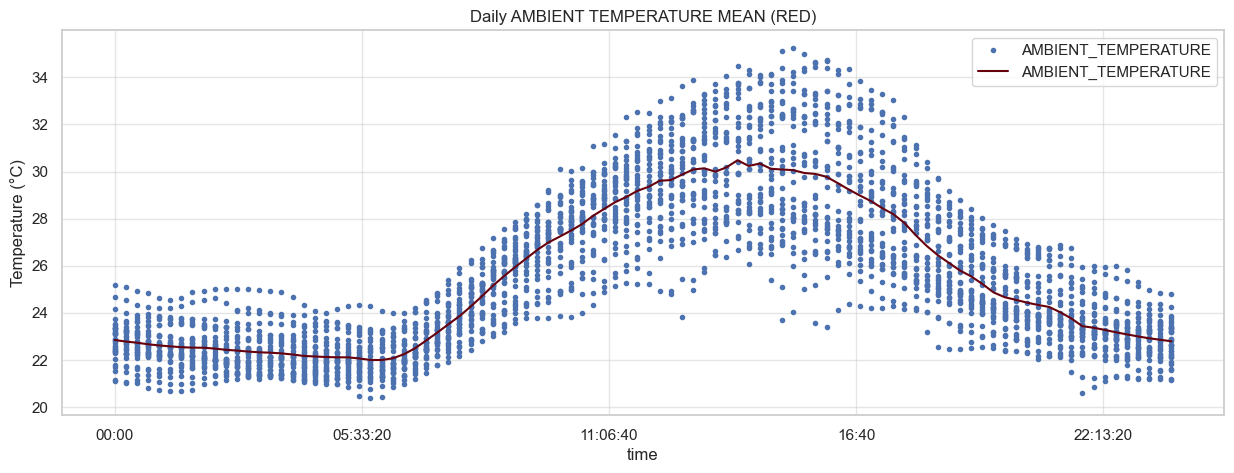

In [54]:
plant1_sensor.plot(x='time', y = 'AMBIENT_TEMPERATURE' , style='b.', figsize=(15,5))
plant1_sensor.groupby('time')['AMBIENT_TEMPERATURE'].agg('mean').plot(legend=True, colormap='Reds_r')
plt.title('Daily AMBIENT TEMPERATURE MEAN (RED)')
plt.ylabel('Temperature (°C)')
plt.show()

In [55]:
ambient = plant1_sensor.pivot_table(values='AMBIENT_TEMPERATURE', index='time', columns='date')

In [56]:
ambient.tail()

date,2020-05-15,2020-05-16,2020-05-17,2020-05-18,2020-05-19,2020-05-20,2020-05-21,2020-05-22,2020-05-23,2020-05-24,...,2020-06-08,2020-06-09,2020-06-10,2020-06-11,2020-06-12,2020-06-13,2020-06-14,2020-06-15,2020-06-16,2020-06-17
time,,,,,,,,,,,,,,,,,,,,,
22:45:00,22.057080,24.492981,21.315892,22.815780,23.393146,24.003129,24.002574,23.214526,25.338855,24.403691,...,23.170805,22.946915,22.014016,23.419015,22.599839,22.265993,23.522461,23.612832,22.872359,22.150570
23:00:00,22.236018,24.461625,21.220532,22.787469,23.230817,23.830852,23.978326,22.361055,25.133763,24.308990,...,23.115568,22.883195,22.087756,23.328575,22.504606,22.227169,23.386562,23.618848,22.962205,22.129816
23:15:00,NaN,24.392568,21.216575,22.856671,22.916650,23.701162,23.922381,21.641128,24.969698,24.175543,...,22.929185,22.892314,22.247858,23.195113,22.398564,22.334206,23.331081,23.602976,22.947974,22.008275
23:30:00,NaN,24.378021,21.273112,22.750576,22.787917,23.589626,23.892236,21.564903,24.838093,24.169597,...,22.616367,22.866815,22.409064,23.027635,22.145038,22.237394,23.444953,23.631051,22.925033,21.969495
23:45:00,NaN,24.249347,21.209418,22.621004,22.638493,23.569009,23.856805,21.605520,24.818829,23.777932,...,22.369204,22.825907,22.643738,22.883351,21.820540,22.205029,23.418154,23.641211,22.892004,21.909288


Text(0, 0.5, 'Temperature (°C)')

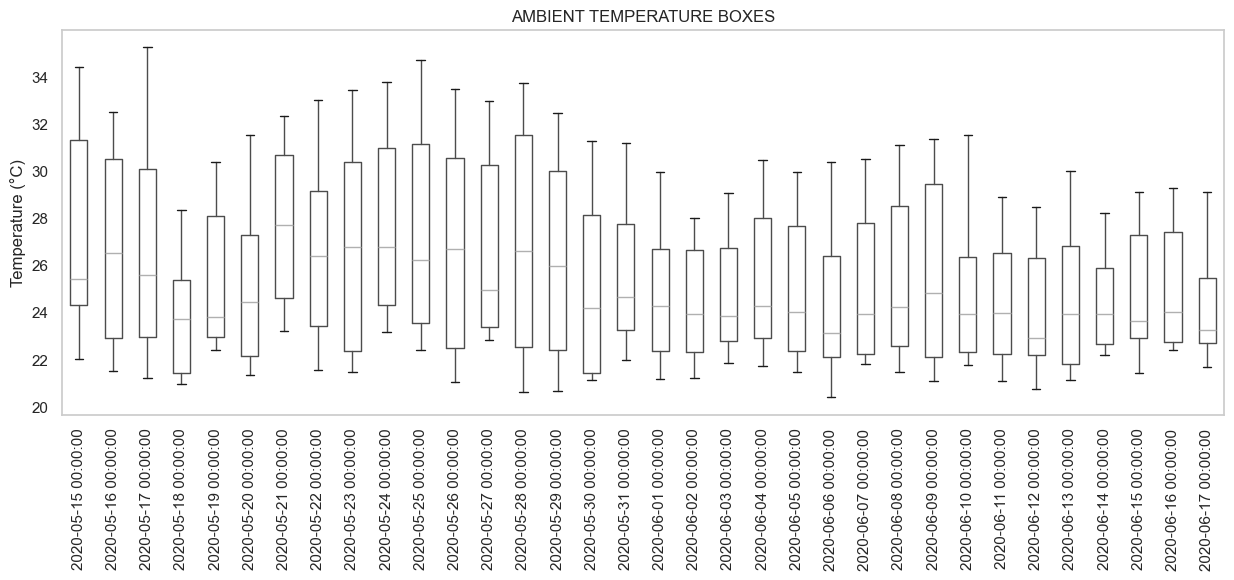

In [57]:
ambient.boxplot(figsize=(15,5), grid=False, rot=90)
plt.title('AMBIENT TEMPERATURE BOXES')
plt.ylabel('Temperature (°C)')

**Which date ambient temperature mean is maximun?**

In [58]:
am_temp = plant1_sensor.groupby('date')['AMBIENT_TEMPERATURE'].agg('mean')

Text(0, 0.5, 'Temperature (°C)')

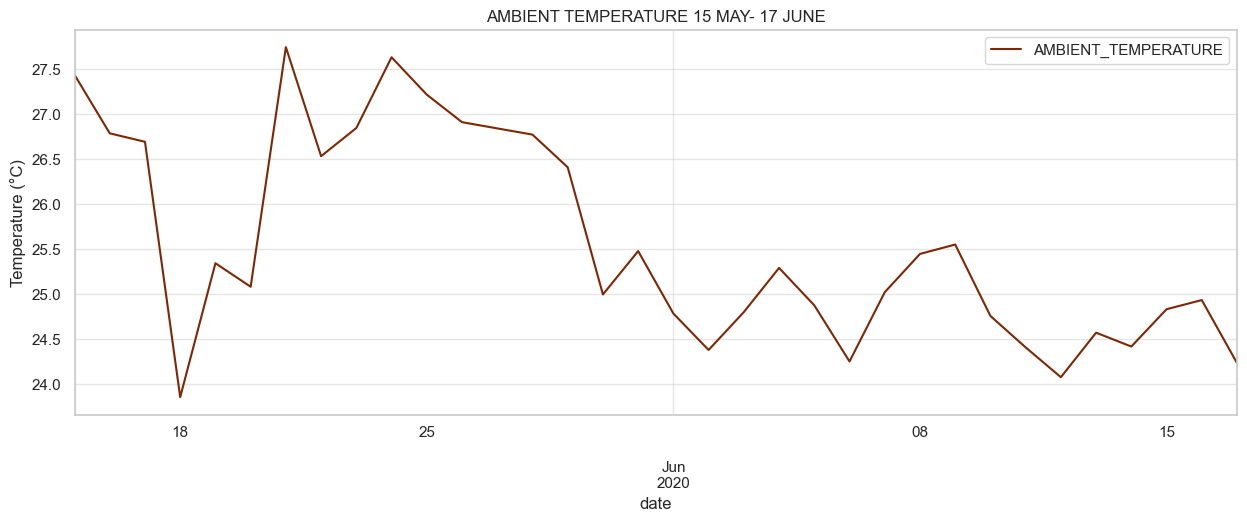

In [59]:
am_temp.plot(grid=True, figsize=(15,5), legend=True, colormap='Oranges_r')
plt.title('AMBIENT TEMPERATURE 15 MAY- 17 JUNE')
plt.ylabel('Temperature (°C)')

**Comment**:

In May, ambiant Temperature in Plant 1 was between 24 and 30°C, this means that May was very hot. But in June ambiant Temperature decreases considerately between 24 and 26°C.

In the next cell, we will seek how % change of ambient Temperature is.

In [60]:
am_change_temp = (am_temp.diff()/am_temp)*100

Text(0.5, 1.0, 'AMBIENT TEMPERATURE %change')

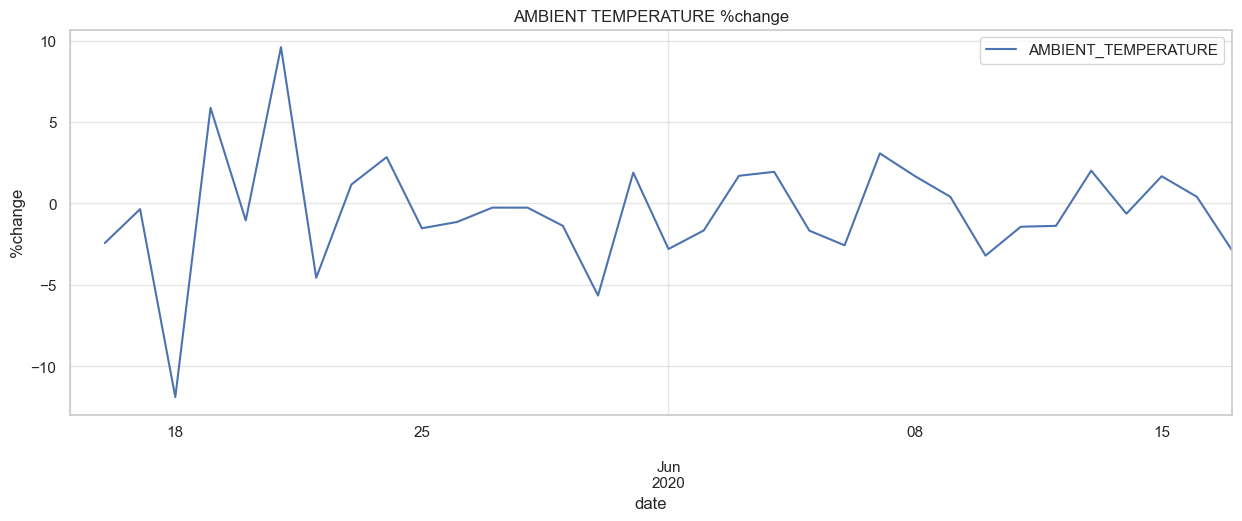

In [62]:
am_change_temp.plot(figsize=(15,5), grid=True, legend=True)
plt.ylabel('%change')
plt.title('AMBIENT TEMPERATURE %change')

**Comment**

1. Sunday 17 May 2020 to Monday 18 May 2020, the ambient Temperature decreases to 10%.

2. Monday 18 May 2020 to Tuesday 19 May 2020, the ambient Temperature increases to 15% and tomorrow decreases to 5%.

3. Wednesday 20 May 2020 to Thursday 21 May 2020, the ambient Temperature increases to 10% and tomorrow decreases to 15%.

4. June month's, the ambiant Temperature %change stabilize between -2.5 and 2.5%. 

## Ambient Temperature: seasonal, trend and residual.

In [63]:
from scipy.signal import periodogram

In [64]:
decomp = sm.tsa.seasonal_decompose(am_temp)

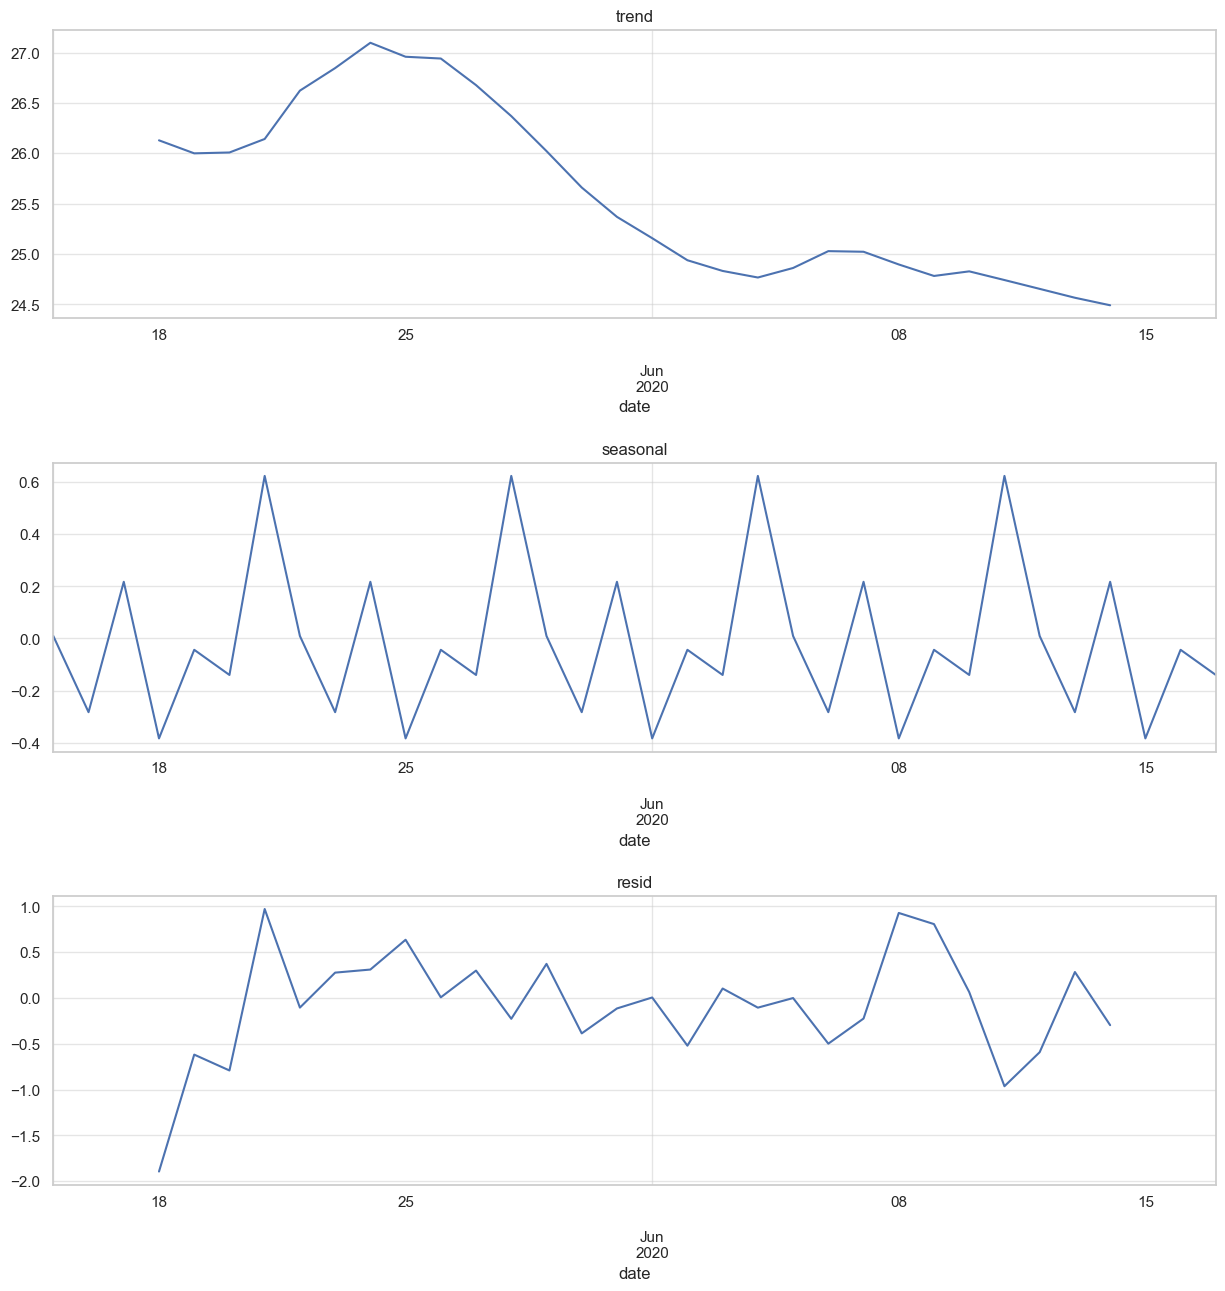

In [65]:
cols = ['trend', 'seasonal', 'resid'] # take all column
data = [decomp.trend, decomp.seasonal, decomp.resid]
gp = plt.figure(figsize=(15,15)) 
    
gp.subplots_adjust(hspace=0.5)
for i in range(1, len(cols)+1):
    ax = gp.add_subplot(3,1, i)
    data[i-1].plot(ax=ax)
    ax.set_title('{}'.format(cols[i-1]))

**Comment**

seasonality of ambient Temperature is the **7 days** to see a maximum of temperature.  

### ``Module Temperature``

Text(0, 0.5, 'Temperature(°C)')

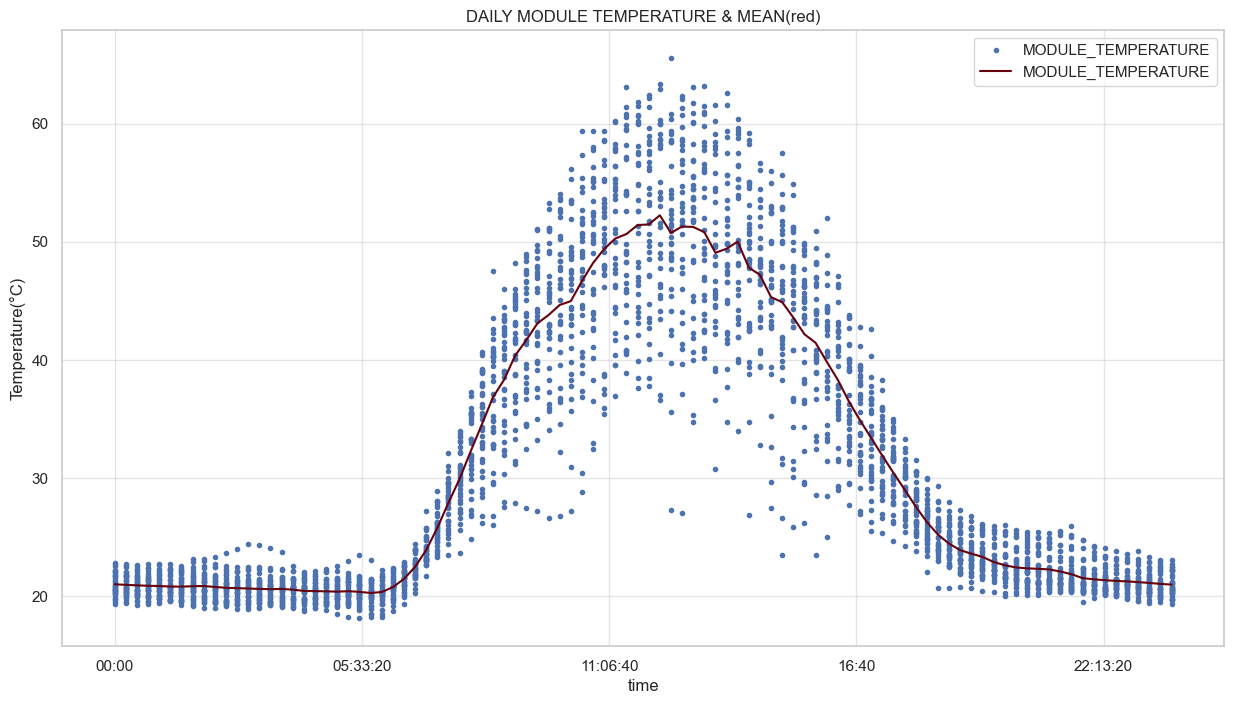

In [66]:
plant1_sensor.plot(x='time', y='MODULE_TEMPERATURE', figsize=(15,8), style='b.')
plant1_sensor.groupby('time')['MODULE_TEMPERATURE'].agg('mean').plot(colormap='Reds_r', legend=True)
plt.title('DAILY MODULE TEMPERATURE & MEAN(red)')
plt.ylabel('Temperature(°C)')

In [67]:
module_temp = plant1_sensor.pivot_table(values='MODULE_TEMPERATURE', index='time', columns='date')

Text(0, 0.5, 'Temperature (°C)')

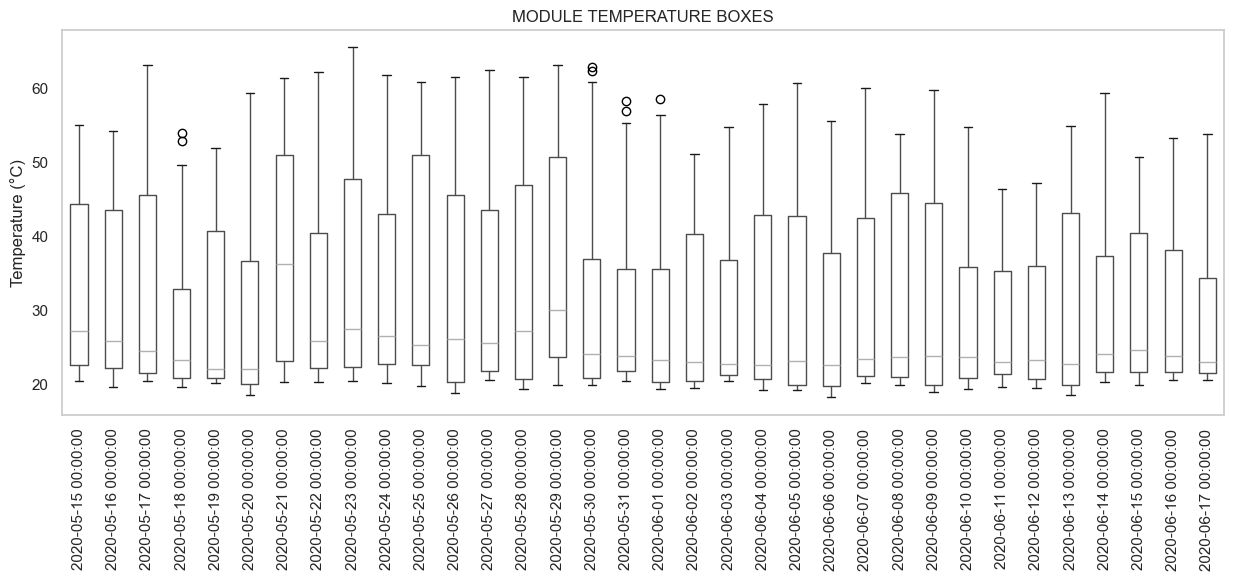

In [68]:
module_temp.boxplot(figsize=(15,5), grid=False, rot=90)
plt.title('MODULE TEMPERATURE BOXES')
plt.ylabel('Temperature (°C)')

**Comment**

Four dates contains outliers: **18-05-2020, 30-05-2020, 31-05-2020, 01-06-2020**. The outlier of these 3 dates occurs precisely at interval time $[11:06:40, 16:40]$. see

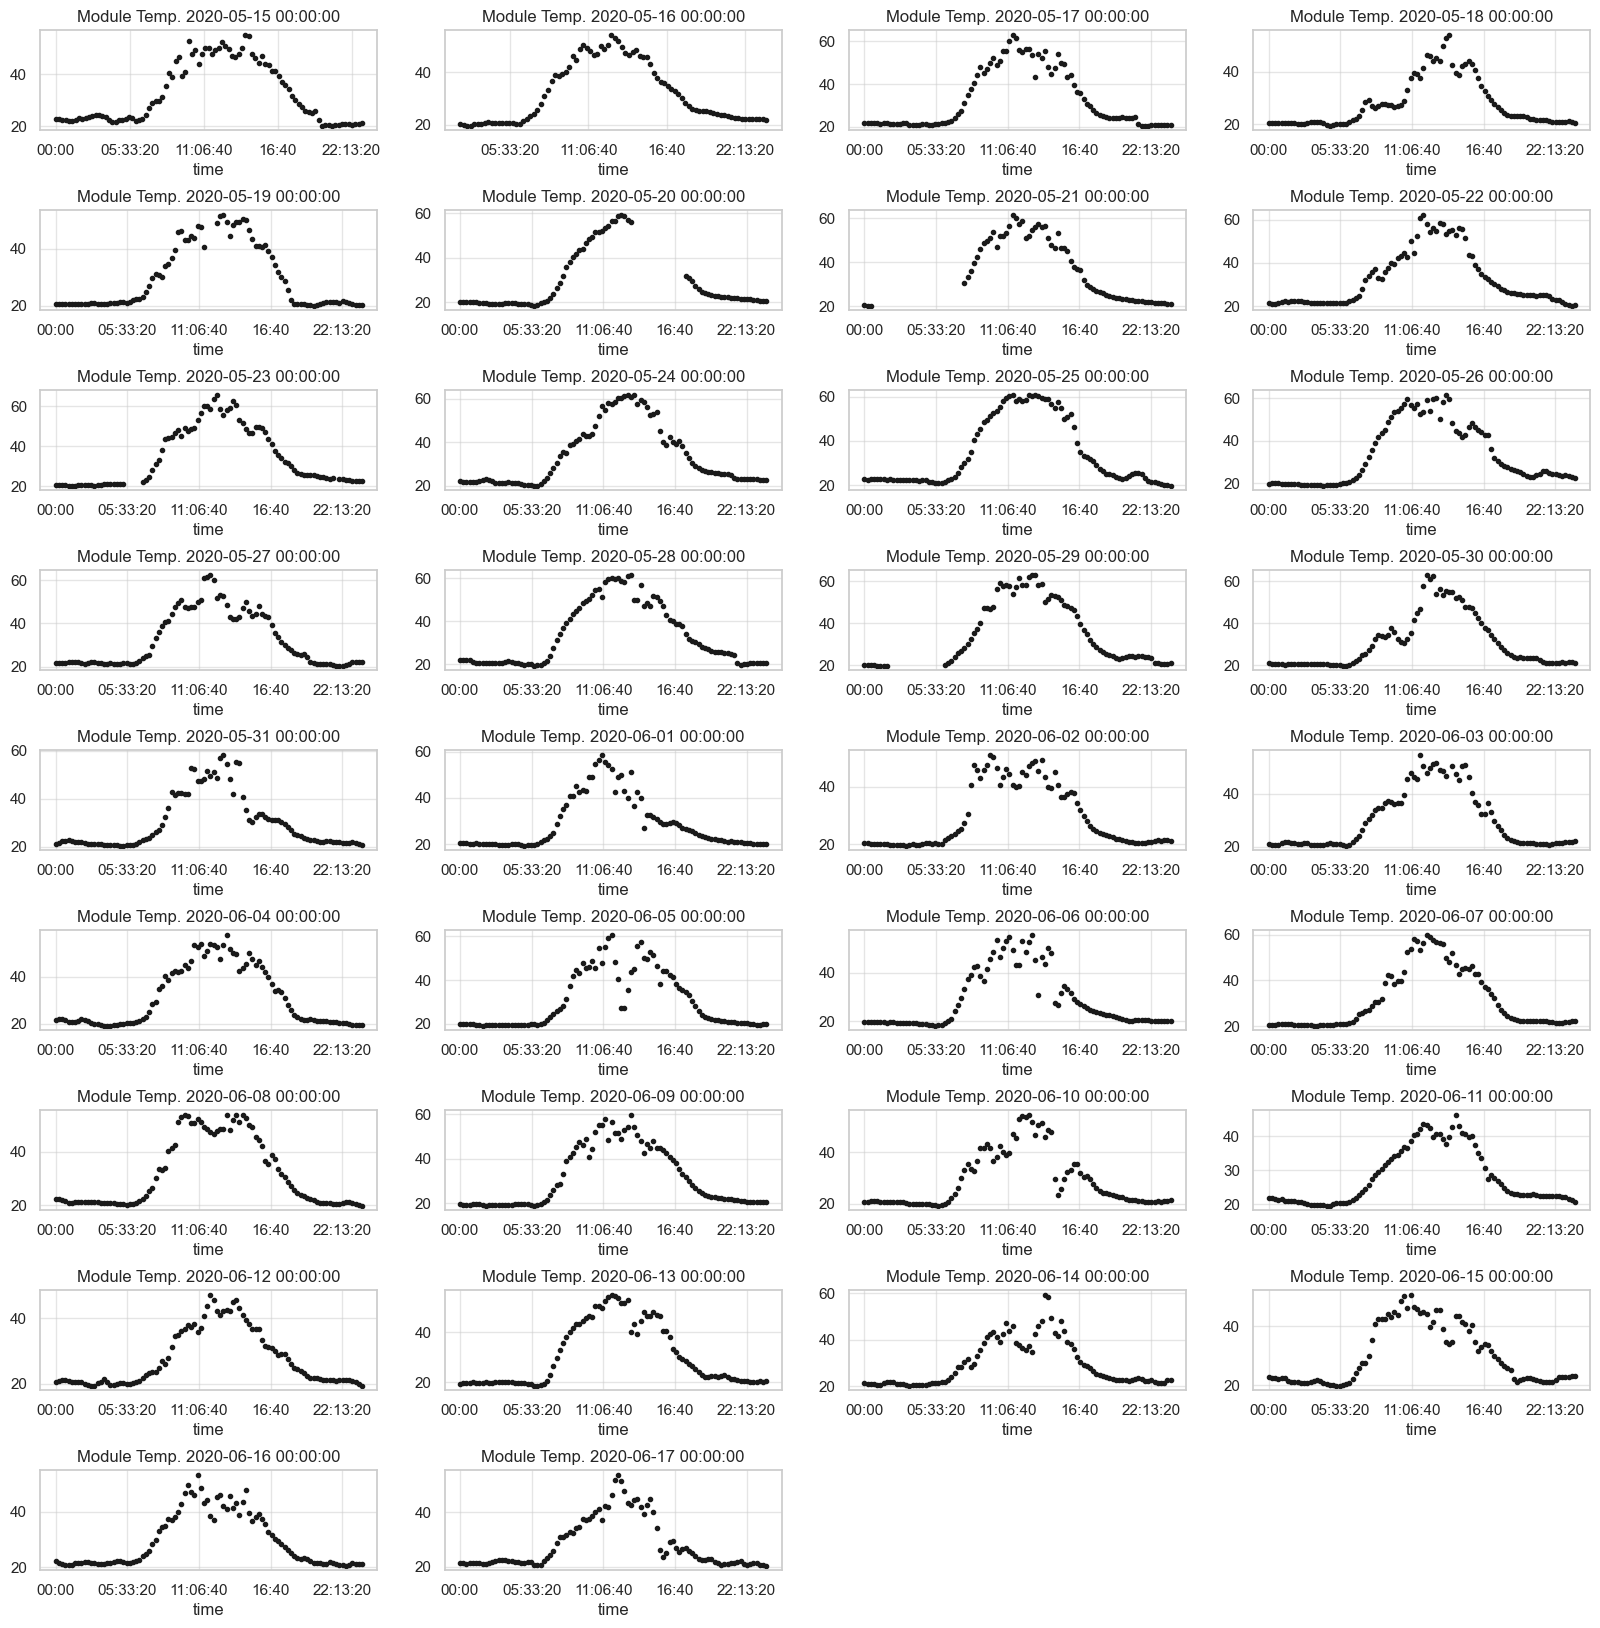

In [69]:
multi_plot(module_temp, row=9,  col=4, title='Module Temp.')

In [70]:
#we can also see also calendar plot
mod_temp = plant1_sensor.groupby('date')['MODULE_TEMPERATURE'].agg('mean')

Text(0, 0.5, 'Temperature (°C)')

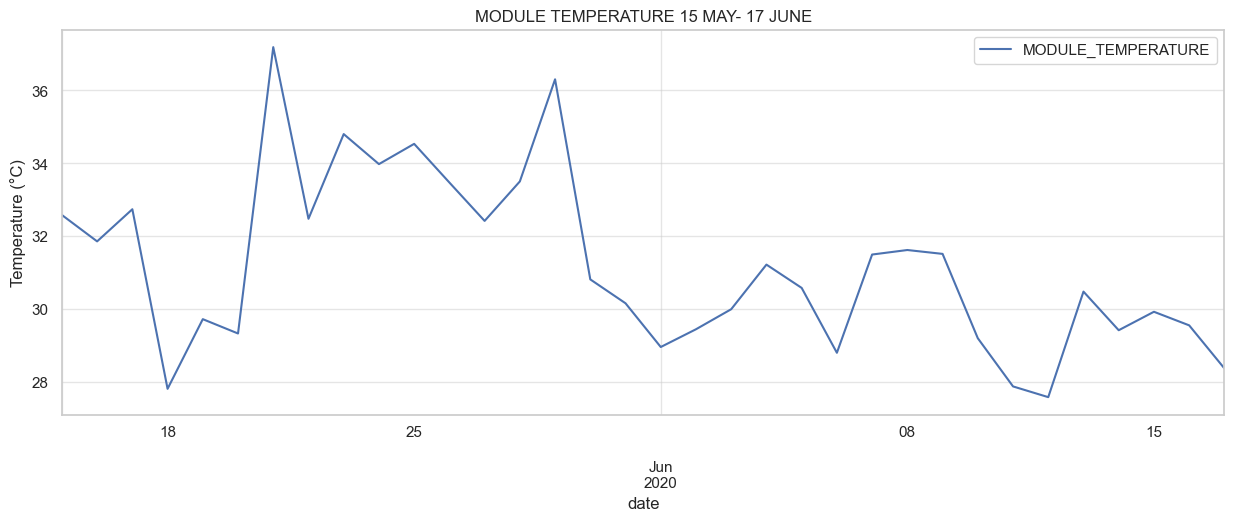

In [71]:
mod_temp.plot(grid=True, figsize=(15,5), legend=True)
plt.title('MODULE TEMPERATURE 15 MAY- 17 JUNE')
plt.ylabel('Temperature (°C)')

**Comment**

May month's have: 2 huges hot date 21 and 29. 

In [72]:
#we plot a %change of MODULE TEMPERATURE.
chan_mod_temp = (mod_temp.diff()/mod_temp)*100

Text(0.5, 1.0, 'MODULE TEMPERATURE %change')

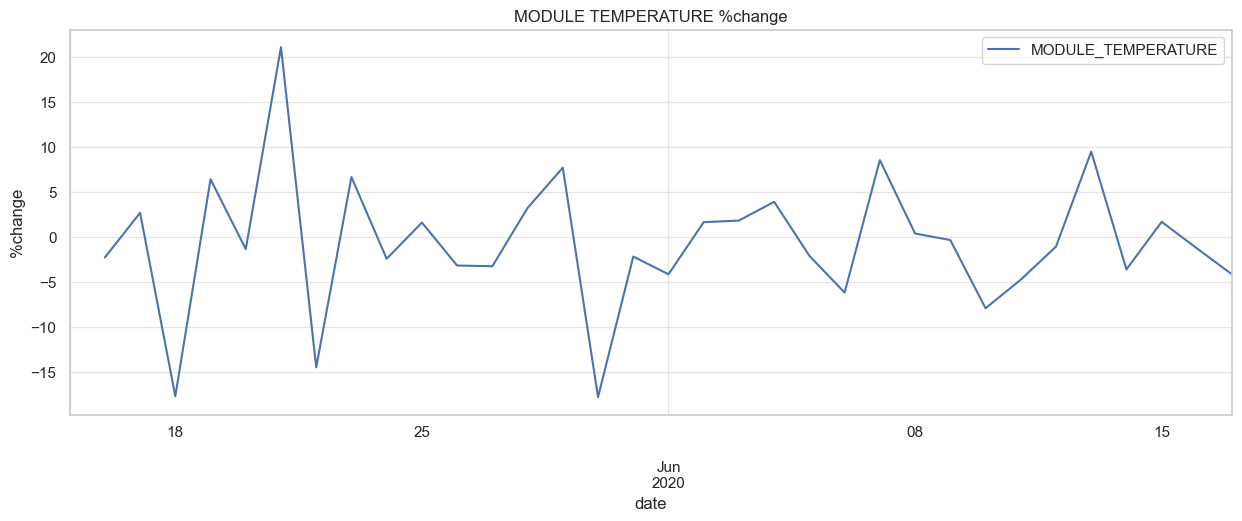

In [73]:
chan_mod_temp.plot(grid=True, legend=True, figsize=(15,5))
plt.ylabel('%change')
plt.title('MODULE TEMPERATURE %change')

### ``Irradiation``

Text(0.5, 1.0, 'IRRADIATION')

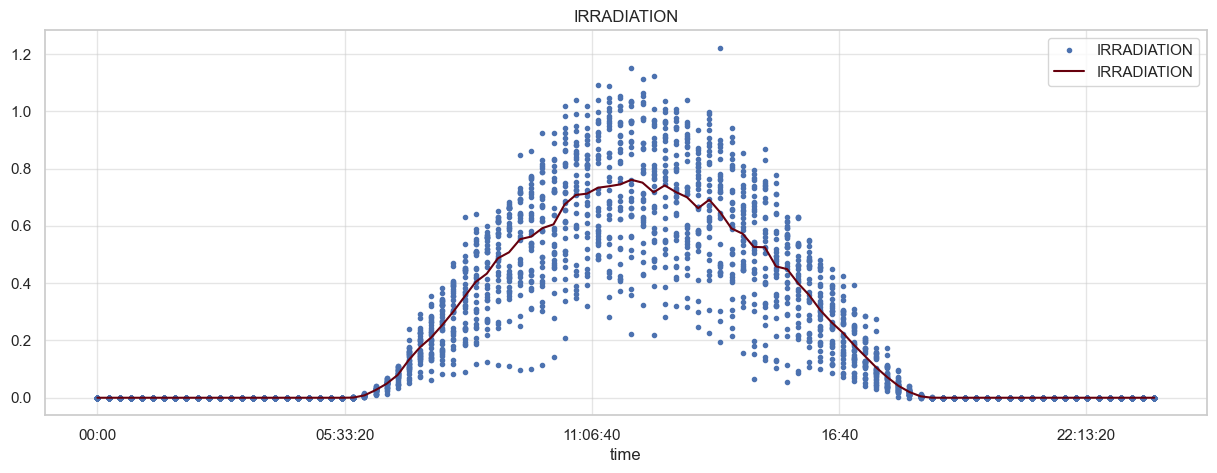

In [74]:
plant1_sensor.plot(x='time', y = 'IRRADIATION', style='.', legend=True, figsize=(15,5))
plant1_sensor.groupby('time')['IRRADIATION'].agg('mean').plot(legend=True, colormap='Reds_r')
plt.title('IRRADIATION')

In [75]:
irra = plant1_sensor.pivot_table(values='IRRADIATION', index='time', columns='date')

In [76]:
irra.tail()

date,2020-05-15,2020-05-16,2020-05-17,2020-05-18,2020-05-19,2020-05-20,2020-05-21,2020-05-22,2020-05-23,2020-05-24,...,2020-06-08,2020-06-09,2020-06-10,2020-06-11,2020-06-12,2020-06-13,2020-06-14,2020-06-15,2020-06-16,2020-06-17
time,,,,,,,,,,,,,,,,,,,,,
22:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23:15:00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23:30:00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23:45:00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Text(0.5, 1.0, 'IRRADIATION BOXES')

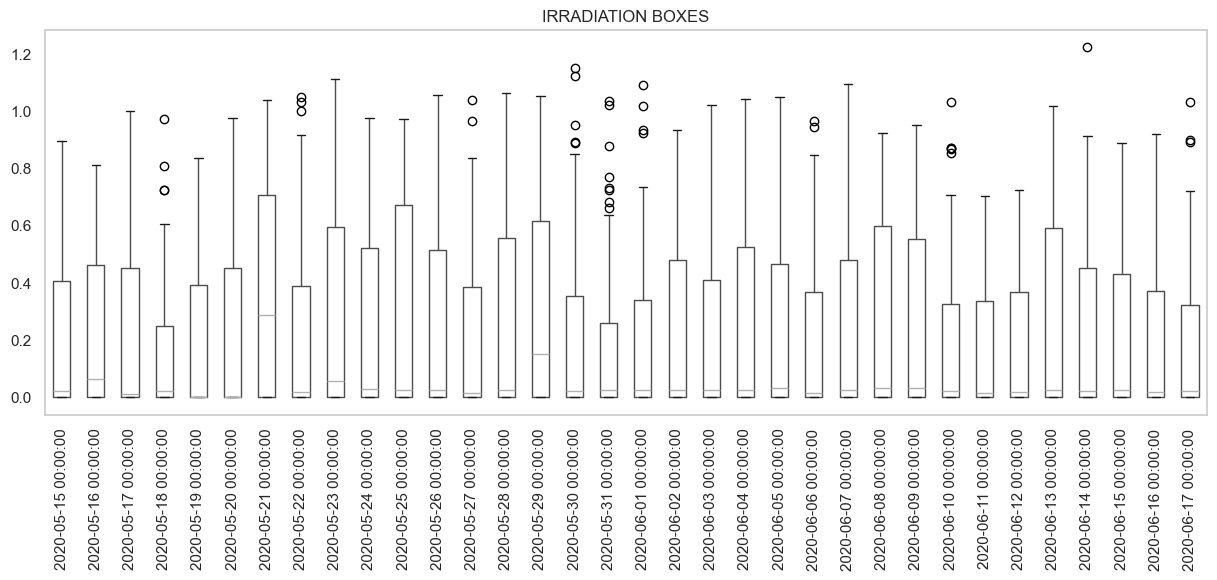

In [77]:
irra.boxplot(figsize=(15,5), rot = 90, grid=False)
plt.title('IRRADIATION BOXES')

In [78]:
rad = plant1_sensor.groupby('date')['IRRADIATION'].agg('sum')

Text(0.5, 1.0, 'IRRADIATION 15 MAY- 17 JUNE')

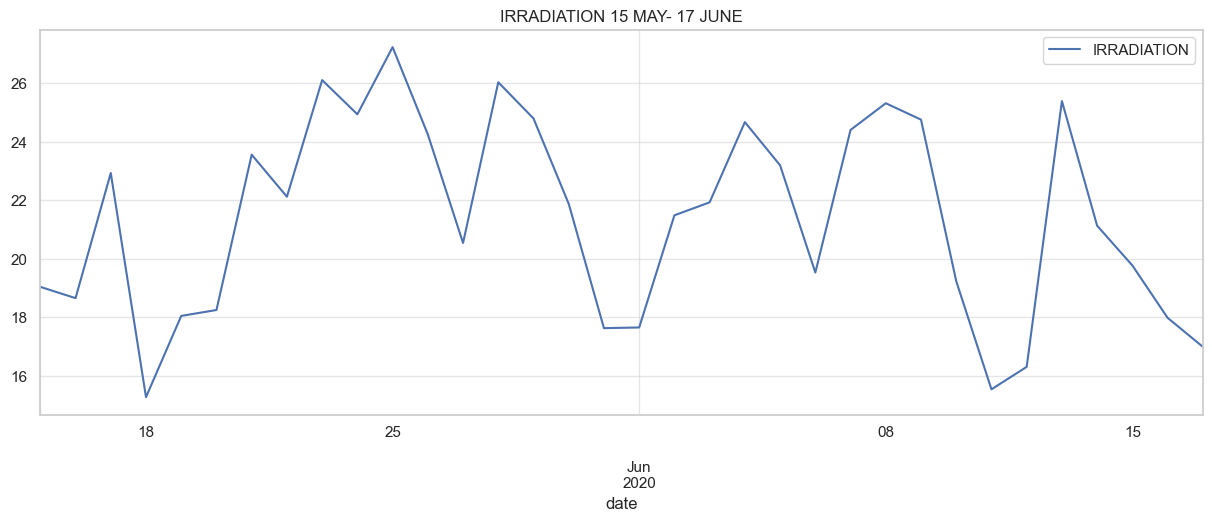

In [79]:
rad.plot(grid=True, figsize=(15,5), legend=True)
plt.title('IRRADIATION 15 MAY- 17 JUNE')

**N.B** Thursday 21 May 2020 is a date where plant 1 are:

1. more produce dc power.

2. ambient temperature, module temperature are maximun.

This date is very special.

# Correlation

In this part, we are making correlation between feature to see how some feature can explain another feature. or see relation between them.

In [80]:
# we are merge our solar power generation data and weather sensor data
power_sensor = plant1_sensor.merge(plant1_data, left_on='DATE_TIME', right_on='DATE_TIME')

In [81]:
power_sensor.tail(3)

,DATE_TIME,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,date_x,time_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,time_y,date_y
93,2020-06-06 23:15:00,22.194932,20.219128,0.0,2020-06-06,23:15:00,0.0,0.0,63099.000,154467647.0,23:15:00,2020-06-06
94,2020-06-06 23:30:00,22.081917,20.148322,0.0,2020-06-06,23:30:00,0.0,0.0,63099.000,154467647.0,23:30:00,2020-06-06
95,2020-06-06 23:45:00,22.123830,20.200745,0.0,2020-06-06,23:45:00,0.0,0.0,58519.375,154467647.0,23:45:00,2020-06-06


In [82]:
#we remove the columns that we do not need
del power_sensor['date_x']
del power_sensor['date_y']
del power_sensor['time_x']
del power_sensor['time_y']

In [83]:
power_sensor.tail(3)

,DATE_TIME,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
93,2020-06-06 23:15:00,22.194932,20.219128,0.0,0.0,0.0,63099.000,154467647.0
94,2020-06-06 23:30:00,22.081917,20.148322,0.0,0.0,0.0,63099.000,154467647.0
95,2020-06-06 23:45:00,22.123830,20.200745,0.0,0.0,0.0,58519.375,154467647.0


In [84]:
power_sensor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            96 non-null     datetime64[ns]
 1   AMBIENT_TEMPERATURE  96 non-null     float64       
 2   MODULE_TEMPERATURE   96 non-null     float64       
 3   IRRADIATION          96 non-null     float64       
 4   DC_POWER             96 non-null     float64       
 5   AC_POWER             96 non-null     float64       
 6   DAILY_YIELD          96 non-null     float64       
 7   TOTAL_YIELD          96 non-null     float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 6.1 KB


In [85]:
#we start correlation
power_sensor.corr(method = 'spearman')


,DATE_TIME,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
DATE_TIME,1.000000,0.251845,0.309034,-0.003453,0.001862,0.001963,0.753671,0.793539
AMBIENT_TEMPERATURE,0.251845,1.000000,0.960608,0.828135,0.838699,0.838296,0.658867,0.295052
MODULE_TEMPERATURE,0.309034,0.960608,1.000000,0.880751,0.887147,0.886816,0.638846,0.344705
IRRADIATION,-0.003453,0.828135,0.880751,1.000000,0.991117,0.991057,0.425997,0.119345
DC_POWER,0.001862,0.838699,0.887147,0.991117,1.000000,0.999985,0.441221,0.149723
AC_POWER,0.001963,0.838296,0.886816,0.991057,0.999985,1.000000,0.441323,0.149824
DAILY_YIELD,0.753671,0.658867,0.638846,0.425997,0.441221,0.441323,1.000000,0.715589
TOTAL_YIELD,0.793539,0.295052,0.344705,0.119345,0.149723,0.149824,0.715589,1.000000


**Comment**

``DAILY_YIELD`` is not correlated with all feature but  ``AMBIENT_TEMPERATURE`` is moreless correlated.

``TOTAL_YIELD`` is also not correlated with all feature. I remove it in the correlation matrix. 

In [86]:
corr = power_sensor.drop(columns=['DAILY_YIELD', 'TOTAL_YIELD']).corr(method = 'spearman')

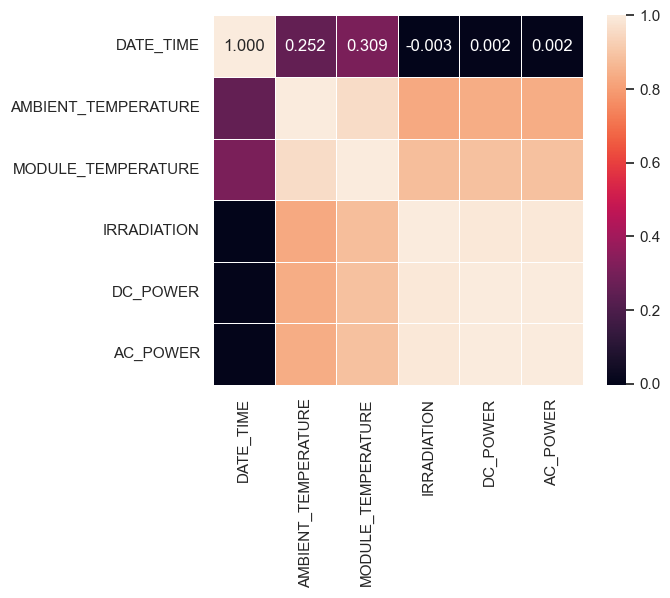

In [87]:
plt.figure(dpi=100)
sns.heatmap(corr, robust=True, annot=True, fmt='0.3f', linewidths=.5, square=True)
plt.show()

C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\ASUS\AppData\Local\

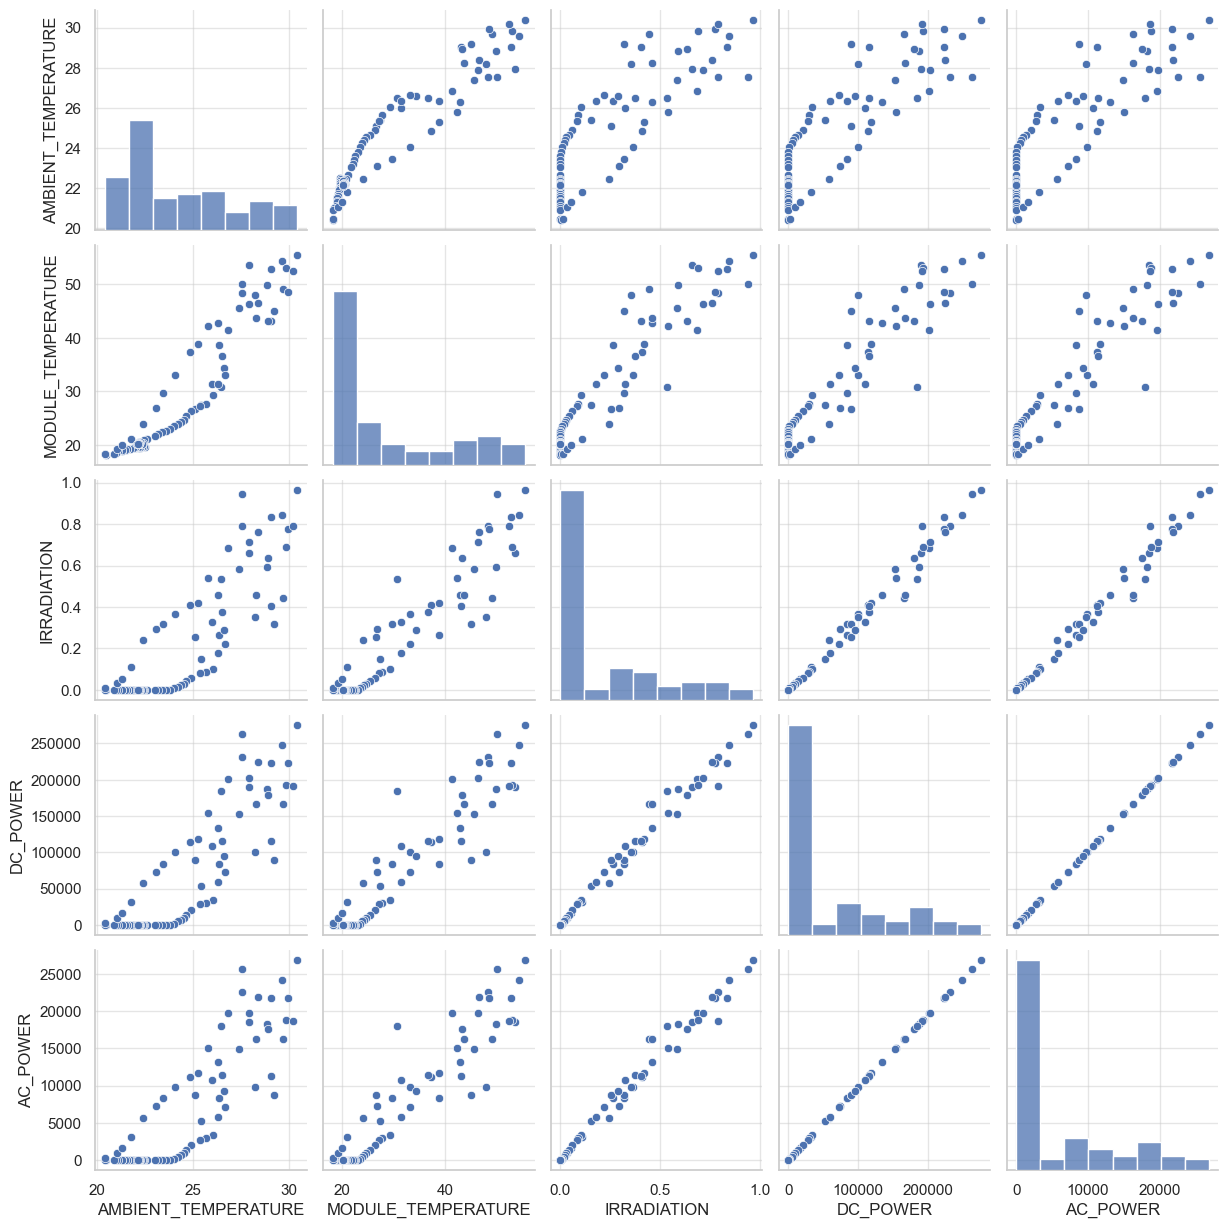

In [88]:
# we make pairplot
sns.pairplot(power_sensor.drop(columns=['DAILY_YIELD', 'TOTAL_YIELD']))
plt.show()

In [76]:
#we plot dc power vs ac power

<Figure size 640x480 with 0 Axes>

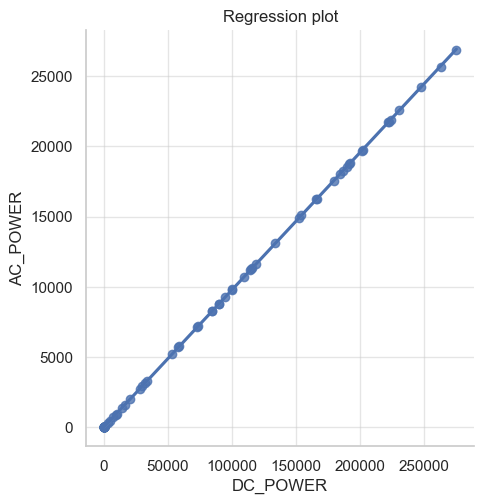

In [89]:
plt.figure(dpi=100)
sns.lmplot(x='DC_POWER', y='AC_POWER', data=power_sensor)
plt.title('Regression plot')
plt.show()

**Comment**

This graph said that inverter convert dc power to ac power linearly. $dc power = 10*ac power$ inverter lost 90% of their power when it convert. 

<Figure size 640x480 with 0 Axes>

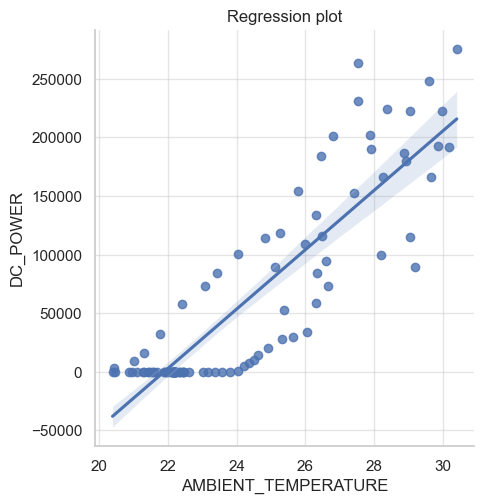

In [90]:
plt.figure(dpi=100)
sns.lmplot(x='AMBIENT_TEMPERATURE', y='DC_POWER', data=power_sensor)
plt.title('Regression plot')
plt.show()

**comment**

DC_power increases non linearly with an Ambient_Temperature.

<Figure size 640x480 with 0 Axes>

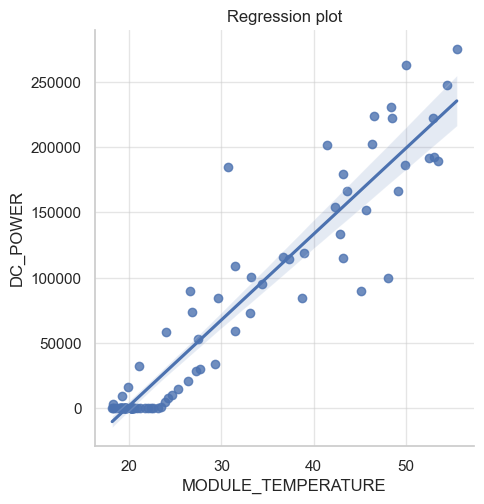

In [91]:
plt.figure(dpi=100)
sns.lmplot(x='MODULE_TEMPERATURE', y='DC_POWER', data=power_sensor)
plt.title('Regression plot')
plt.show()

**comment**

``DC_POWER`` is produced linearly by ``MODULE_TEMPERATURE`` with some variability. 

<Figure size 640x480 with 0 Axes>

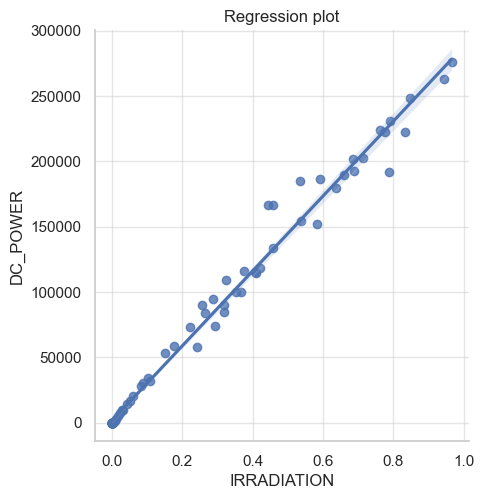

In [92]:
plt.figure(dpi=100)
sns.lmplot(x='IRRADIATION', y='DC_POWER', data=power_sensor)
plt.title('Regression plot')
plt.show()

**Comment**

DC_Power increase with IRRADIATION.

What happens if I introuduce a difference Temperature between ``AMBIENT_TEMPERATURE`` AND ``MODULE_TEMPERATURE``.

In [93]:
# we introduce DELTA_TEMPERATURE
power_sensor['DELTA_TEMPERATURE'] = abs(power_sensor.AMBIENT_TEMPERATURE - power_sensor.MODULE_TEMPERATURE)

In [94]:
# we check if all is ok
power_sensor.tail(3)

,DATE_TIME,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,DELTA_TEMPERATURE
93,2020-06-06 23:15:00,22.194932,20.219128,0.0,0.0,0.0,63099.000,154467647.0,1.975804
94,2020-06-06 23:30:00,22.081917,20.148322,0.0,0.0,0.0,63099.000,154467647.0,1.933596
95,2020-06-06 23:45:00,22.123830,20.200745,0.0,0.0,0.0,58519.375,154467647.0,1.923086


In [95]:
#now we use correlation
power_sensor.corr(method='spearman')['DELTA_TEMPERATURE']

DATE_TIME             -0.387073
AMBIENT_TEMPERATURE    0.575244
MODULE_TEMPERATURE     0.549539
IRRADIATION            0.658678
DC_POWER               0.671656
AC_POWER               0.670736
DAILY_YIELD           -0.054804
TOTAL_YIELD           -0.133650
DELTA_TEMPERATURE      1.000000
Name: DELTA_TEMPERATURE, dtype: float64

**comment**

we remark that YIELD does not depend on ``DELTA_TEMPERATURE`` also.

Text(0.5, 1.0, 'correlation between DC_POWER and DELTA_TEMPERATURE')

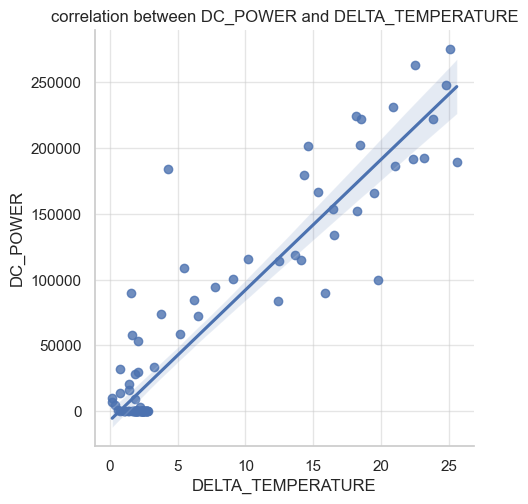

In [96]:
sns.lmplot(x='DELTA_TEMPERATURE', y='DC_POWER', data=power_sensor)
plt.title('correlation between DC_POWER and DELTA_TEMPERATURE')

**comment**

We know that $\dot Q \propto \Delta T$.So, we could say that ``DC_POWER`` is influenced by heat transfer.

Text(0.5, 1.0, 'Regression plot')

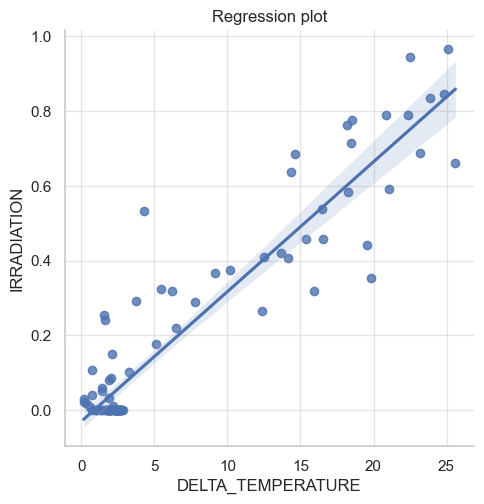

In [97]:
sns.lmplot(x='DELTA_TEMPERATURE', y='IRRADIATION', data=power_sensor)
plt.title('Regression plot')

**comment**

``IRRADIATION`` of Module and Heat Transfert between ambient air and Module are very well correlated.

**short conclusion**

In this section, we conclude that:

1. Yield does not depend on the Temperature, the dc/ac power and irradiation.

2. the transfert function between dc and ac power is linear.

3. dc power is indeed influenced by the ambient temperature, by the temperature of the module, by the irradiation and finally by the heat transfer between the module and the air.

4. all 22 Inverters of Plant I lost 90% of their dc power when it convert.

## Comparison of two power plants

### Plant 1 data vs Plant2 data

In [98]:
file2 = 'Plant_2_Generation_Data.csv'

In [99]:
plant2_data = pd.read_csv(file2)

In [100]:
plant2_data.head(3)

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,4136001,4UPUqMRk7TRMgml,0.0,0.0,9425.000000,2.429011e+06
1,2020-05-15 00:00:00,4136001,81aHJ1q11NBPMrL,0.0,0.0,0.000000,1.215279e+09
2,2020-05-15 00:00:00,4136001,9kRcWv60rDACzjR,0.0,0.0,3075.333333,2.247720e+09


In [101]:
plant2_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67698 entries, 0 to 67697
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    67698 non-null  object 
 1   PLANT_ID     67698 non-null  int64  
 2   SOURCE_KEY   67698 non-null  object 
 3   DC_POWER     67698 non-null  float64
 4   AC_POWER     67698 non-null  float64
 5   DAILY_YIELD  67698 non-null  float64
 6   TOTAL_YIELD  67698 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.6+ MB


In [102]:
#we compute a sum of 22 inverters
plant2_data = plant2_data.groupby('DATE_TIME')[['DC_POWER','AC_POWER', 'DAILY_YIELD','TOTAL_YIELD']].agg('sum').reset_index()

In [103]:
plant2_data['DATE_TIME'] = pd.to_datetime(plant2_data['DATE_TIME'], errors='coerce')
plant2_data['time'] = plant2_data['DATE_TIME'].dt.time
plant2_data['date'] = pd.to_datetime(plant2_data['DATE_TIME'].dt.date)

In [104]:
plant2_data.tail(3)


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,time,date
3256,2020-06-17 23:15:00,0.0,0.0,93040.0,1.419408e+10,23:15:00,2020-06-17
3257,2020-06-17 23:30:00,0.0,0.0,93040.0,1.419408e+10,23:30:00,2020-06-17
3258,2020-06-17 23:45:00,0.0,0.0,93040.0,1.419408e+10,23:45:00,2020-06-17


In [105]:
plant2_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3259 entries, 0 to 3258
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE_TIME    3259 non-null   datetime64[ns]
 1   DC_POWER     3259 non-null   float64       
 2   AC_POWER     3259 non-null   float64       
 3   DAILY_YIELD  3259 non-null   float64       
 4   TOTAL_YIELD  3259 non-null   float64       
 5   time         3259 non-null   object        
 6   date         3259 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(4), object(1)
memory usage: 178.4+ KB


Text(0, 0.5, 'Power (KW)')

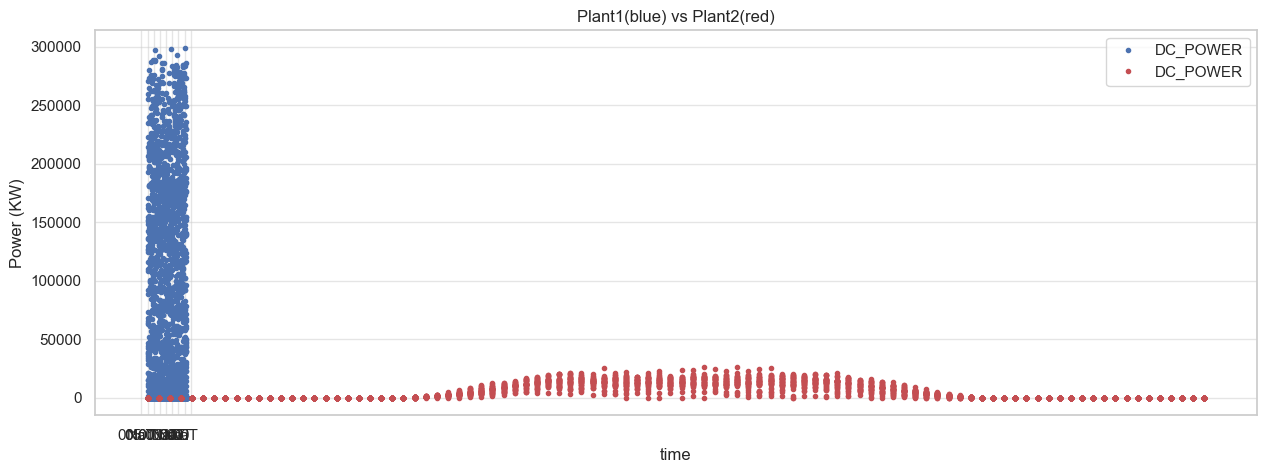

In [106]:
#we conpare a dc power of two plant
ax = plant1_data.plot(x='time', y='DC_POWER', figsize=(15,5), legend=True, style='b.')
plant2_data.plot(x='time', y='DC_POWER', legend=True, style='r.', ax=ax)
plt.title('Plant1(blue) vs Plant2(red)')
plt.ylabel('Power (KW)')

Plant 1 produces dc power 6 time than plant 2 in daily

Text(0, 0.5, 'Power (KW)')

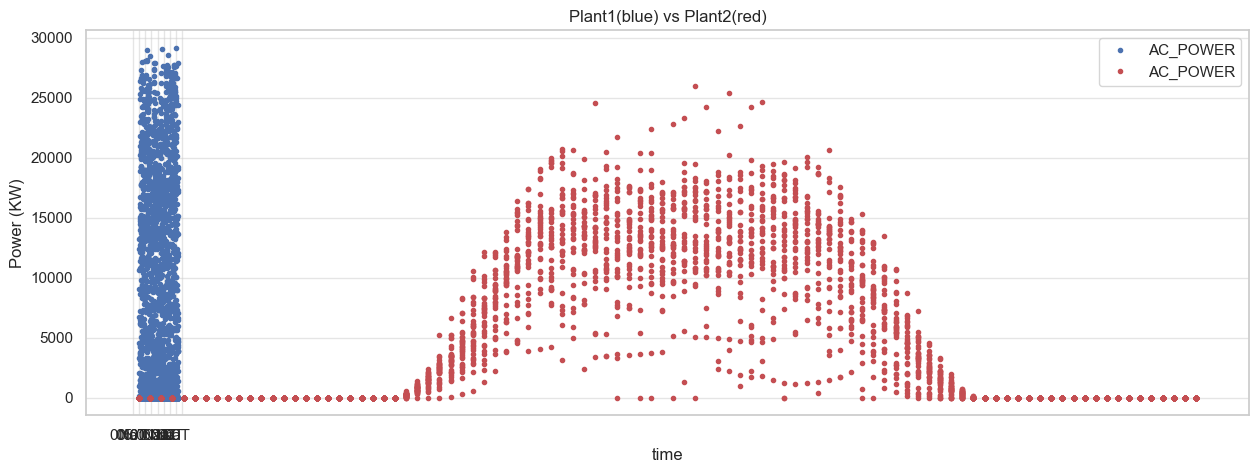

In [107]:
#we conpare a dc power of two plant
ax1 = plant1_data.plot(x='time', y='AC_POWER', figsize=(15,5), legend=True, style='b.', )
plant2_data.plot(x='time', y='AC_POWER', legend=True, style='r.', ax=ax1)
plt.title('Plant1(blue) vs Plant2(red)')
plt.ylabel('Power (KW)')

The two plants are almost the same ac power

In [108]:
p2_daily_dc = plant2_data.groupby('date')['DC_POWER'].agg('sum')

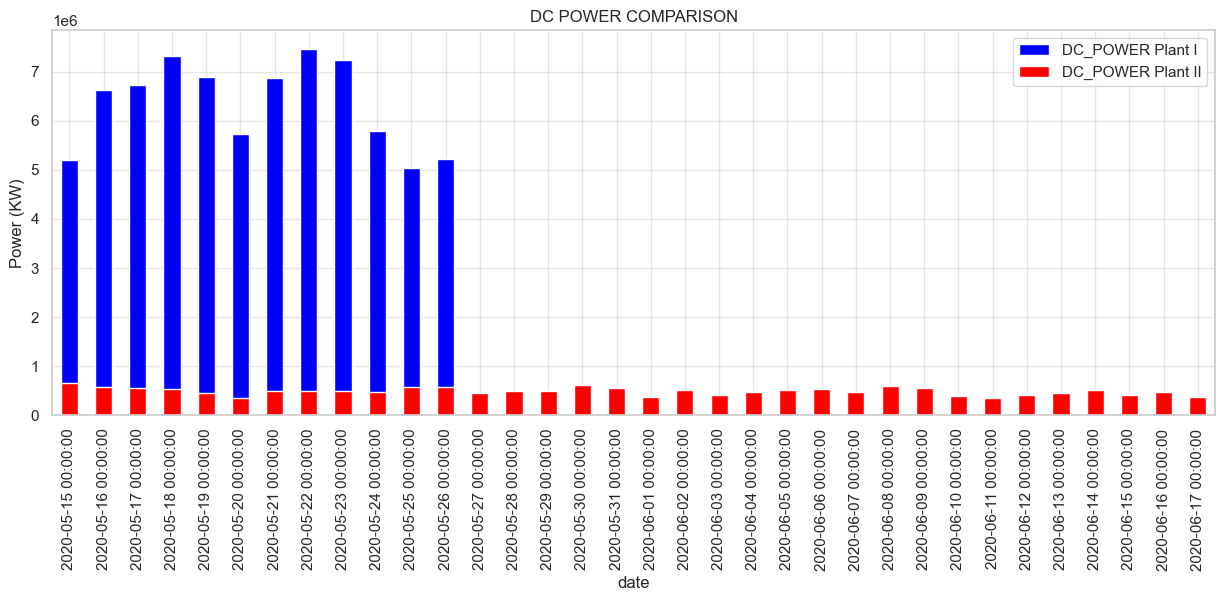

In [109]:
axh = daily_dc.plot.bar(legend=True, figsize=(15,5), color='Blue', label='DC_POWER Plant I')
p2_daily_dc.plot.bar(legend=True, color='Red', label='DC_POWER Plant II', stacked=False)
plt.title('DC POWER COMPARISON')
plt.ylabel('Power (KW)')
plt.show()

Each date plant1 is huge to produce a dc power but plant 2 reach almost 1 GW.

In [110]:
daily_ac = plant1_data.groupby('date')['AC_POWER'].agg('sum')
p2_daily_ac = plant2_data.groupby('date')['AC_POWER'].agg('sum')

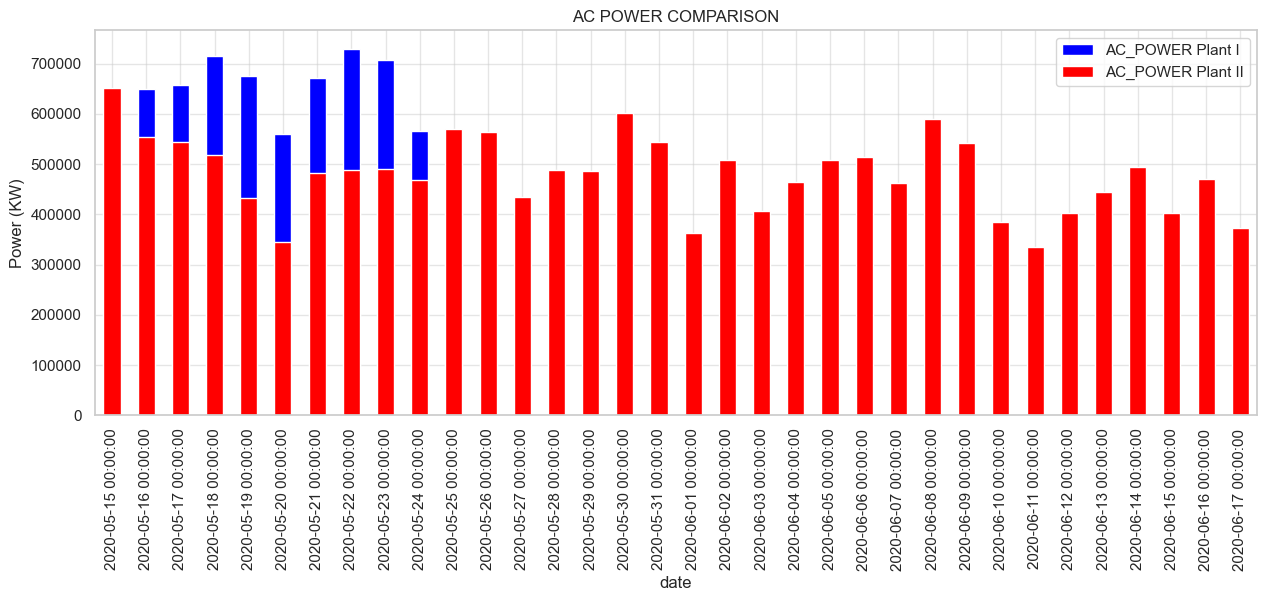

In [111]:
ac = daily_ac.plot.bar(legend=True, figsize=(15,5), color='Blue', label='AC_POWER Plant I')
p2_daily_ac.plot.bar(legend=True, color='Red', label='AC_POWER Plant II')
plt.title('AC POWER COMPARISON')
plt.ylabel('Power (KW)')
plt.show()

Plant I and Plant II are almost same to produce a ac power for each day.

In [112]:
#compute daily_yield for each date
p2_dyield = plant2_data.groupby('date')['DAILY_YIELD'].agg('sum')

Text(0.5, 1.0, 'DAILY YIELD COMPARISON')

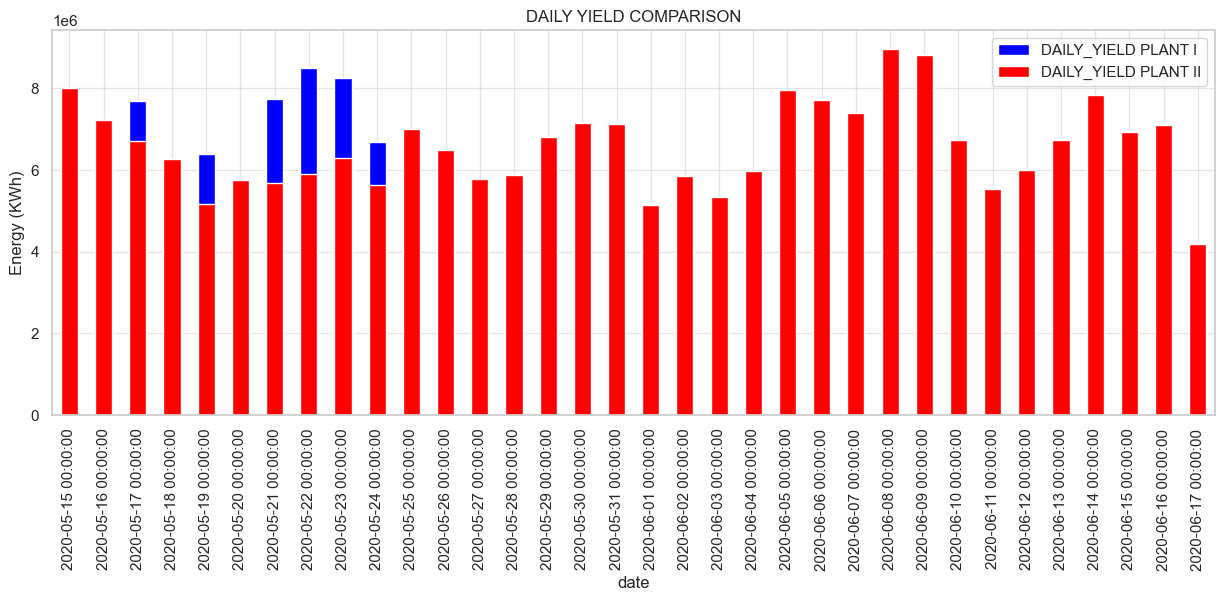

In [113]:
dy = dyield.plot.bar(figsize=(15,5), legend=True, label='DAILY_YIELD PLANT I', color='Blue')
p2_dyield.plot.bar(legend=True, label='DAILY_YIELD PLANT II', color='Red')
plt.ylabel('Energy (KWh)')
plt.title('DAILY YIELD COMPARISON')

Plant I and plant II have almost same daily yield but certain days, they are differents

In [114]:
#compute a average total_yield for plant I for each day
tyield = plant1_data.groupby('date')['TOTAL_YIELD'].agg('mean')

#compute a average total_yield for plant II for each day
p2_tyield = plant2_data.groupby('date')['TOTAL_YIELD'].agg('mean')

<Axes: xlabel='date'>

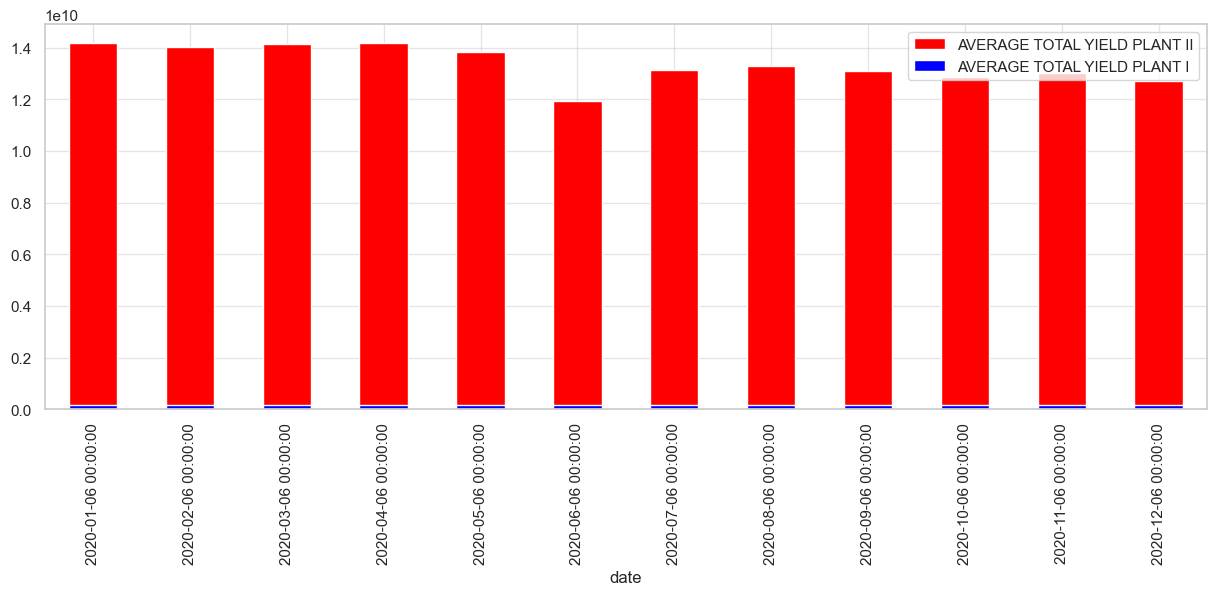

In [115]:
aver = p2_tyield.plot.bar(figsize=(15,5), legend=True, label='AVERAGE TOTAL YIELD PLANT II', color='Red')
tyield.plot.bar(legend=True, label='AVERAGE TOTAL YIELD PLANT I', color='Blue',ax=aver)

The gap between average total yield for plant II and average total yield for plant I for each date is very large. 

## Plant I weather sensor vs Plant II weather sensor

In [116]:
file3 = 'Plant_2_Weather_Sensor_Data.csv'

In [117]:
plant2_sensor = pd.read_csv(file3)

In [118]:
plant2_sensor.tail()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
3254,2020-06-17 22:45:00,4136001,iq8k7ZNt4Mwm3w0,23.511703,22.856201,0.0
3255,2020-06-17 23:00:00,4136001,iq8k7ZNt4Mwm3w0,23.482282,22.744190,0.0
3256,2020-06-17 23:15:00,4136001,iq8k7ZNt4Mwm3w0,23.354743,22.492245,0.0
3257,2020-06-17 23:30:00,4136001,iq8k7ZNt4Mwm3w0,23.291048,22.373909,0.0
3258,2020-06-17 23:45:00,4136001,iq8k7ZNt4Mwm3w0,23.202871,22.535908,0.0


In [119]:
plant2_sensor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3259 entries, 0 to 3258
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3259 non-null   object 
 1   PLANT_ID             3259 non-null   int64  
 2   SOURCE_KEY           3259 non-null   object 
 3   AMBIENT_TEMPERATURE  3259 non-null   float64
 4   MODULE_TEMPERATURE   3259 non-null   float64
 5   IRRADIATION          3259 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 152.9+ KB


In [120]:
plant2_sensor['DATE_TIME'] = pd.to_datetime(plant2_sensor['DATE_TIME'], errors='coerce')

In [121]:
# same work cleaning data for plant II
plant2_sensor['date'] = pd.to_datetime(pd.to_datetime(plant2_sensor['DATE_TIME']).dt.date)
plant2_sensor['time'] = pd.to_datetime(plant2_sensor['DATE_TIME']).dt.time


del plant2_sensor['PLANT_ID']
del plant2_sensor['SOURCE_KEY']

In [122]:
plant2_sensor.head()

,DATE_TIME,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,date,time
0,2020-05-15 00:00:00,27.004764,25.060789,0.0,2020-05-15,00:00:00
1,2020-05-15 00:15:00,26.880811,24.421869,0.0,2020-05-15,00:15:00
2,2020-05-15 00:30:00,26.682055,24.427290,0.0,2020-05-15,00:30:00
3,2020-05-15 00:45:00,26.500589,24.420678,0.0,2020-05-15,00:45:00
4,2020-05-15 01:00:00,26.596148,25.088210,0.0,2020-05-15,01:00:00


Text(0, 0.5, 'Temperature (°C)')

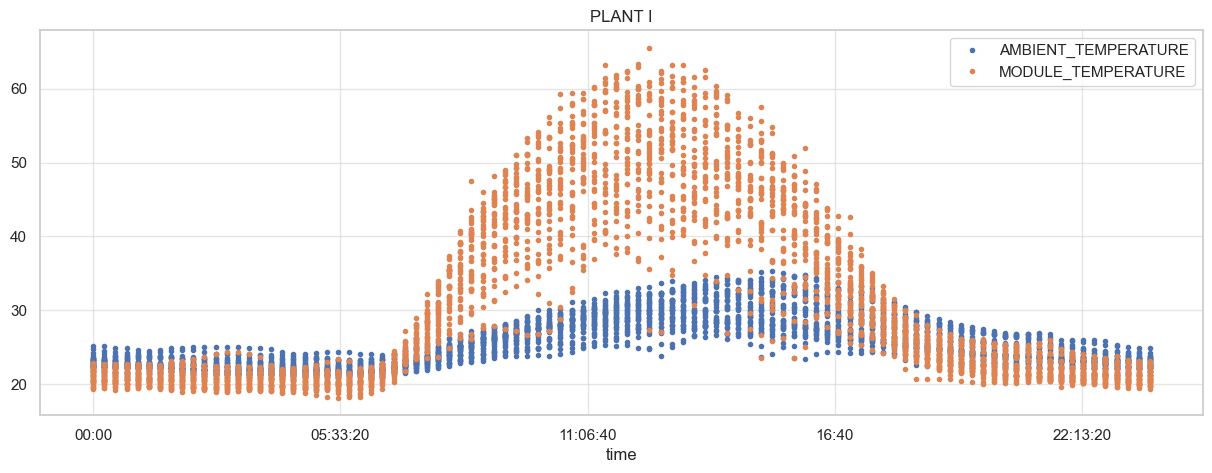

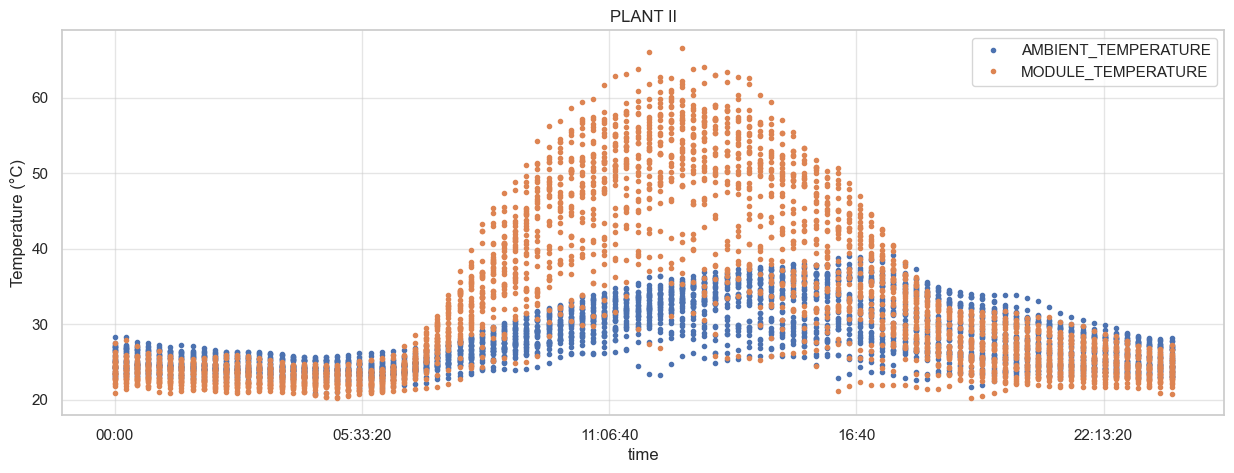

In [123]:
plant1_sensor[['AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','time']].plot(x='time', label='Plant I', title='PLANT I', figsize=(15,5), style='.')
plant2_sensor[['AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','time']].plot(x='time', label='Plant II', title='PLANT II', figsize=(15,5), style='.')
plt.ylabel('Temperature (°C)')

Text(0.5, 1.0, 'IRRADIATION COMPARISON')

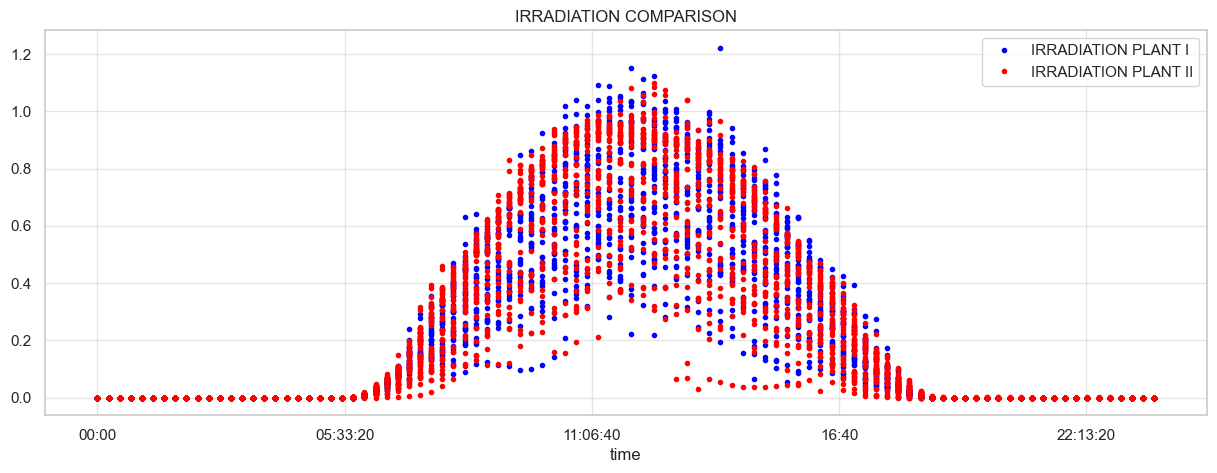

In [124]:
#compare IRRADIATION PLANT I VS PLANT II
aq = plant1_sensor.plot(x='time', y='IRRADIATION', legend=True, label='IRRADIATION PLANT I', color='Blue', style='.', figsize=(15,5))
plant2_sensor.plot(x='time', y='IRRADIATION', legend=True, label='IRRADIATION PLANT II',  color='Red', style='.', ax=aq)
plt.title('IRRADIATION COMPARISON')

Plant I and Plant II have same  IRRADIATION  distribution between 05:33:20 and 18:00:00

## correlation for PLANT II

In [125]:
# we are merging our solar power generation data and weather sensor data for plant 2
sensorData = plant2_sensor.merge(plant2_data, left_on='DATE_TIME', right_on='DATE_TIME')

In [126]:
#we remove the columns that we do not need
del sensorData['date_x']
del sensorData['date_y']
del sensorData['time_x']
del sensorData['time_y']

In [127]:
sensorData.tail()

,DATE_TIME,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
3254,2020-06-17 22:45:00,23.511703,22.856201,0.0,0.0,0.0,93040.0,1.419408e+10
3255,2020-06-17 23:00:00,23.482282,22.744190,0.0,0.0,0.0,93040.0,1.419408e+10
3256,2020-06-17 23:15:00,23.354743,22.492245,0.0,0.0,0.0,93040.0,1.419408e+10
3257,2020-06-17 23:30:00,23.291048,22.373909,0.0,0.0,0.0,93040.0,1.419408e+10
3258,2020-06-17 23:45:00,23.202871,22.535908,0.0,0.0,0.0,93040.0,1.419408e+10


I create five new feature DELTA_TEMPERATURE, NEW_DAILY_YIELD, NEW_TOTAL_YIELD, NEW_AMBIENT_TEMPERATURE and NEW_MODULE_TEMPERATURE.

delta temperature = ambient temperature - module temperature. All other new variable is just the first derivative in time.

1. New daily yield is the next daily yield - previous daily yield.
2. new total yield is the next total yield - previous total yield
3. new ambient temperature is the next ambient temperature - previous ambient temperature.

and so on, do not forget that it is after 15 min of each daily 

In [128]:
sensorData = sensorData.assign(DELTA_TEMPERATURE = abs(sensorData.MODULE_TEMPERATURE - sensorData.AMBIENT_TEMPERATURE),
                              NEW_DAILY_YIELD = sensorData.DAILY_YIELD.diff(),
                              NEW_TOTAL_YIELD = sensorData.TOTAL_YIELD.diff(),
                              NEW_AMBIENT_TEMPERATURE = sensorData.AMBIENT_TEMPERATURE.diff(),
                              NEW_MODULE_TEMPERATURE = sensorData.MODULE_TEMPERATURE.diff(),
                              NEW_AC_POWER = sensorData.AC_POWER.diff())

In [129]:
#see
sensorData.head()

,DATE_TIME,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,DELTA_TEMPERATURE,NEW_DAILY_YIELD,NEW_TOTAL_YIELD,NEW_AMBIENT_TEMPERATURE,NEW_MODULE_TEMPERATURE,NEW_AC_POWER
0,2020-05-15 00:00:00,27.004764,25.060789,0.0,0.0,0.0,48899.938095,1.418960e+10,1.943975,NaN,NaN,NaN,NaN,NaN
1,2020-05-15 00:15:00,26.880811,24.421869,0.0,0.0,0.0,28401.000000,1.418960e+10,2.458943,-20498.938095,0.0,-0.123952,-0.638920,0.0
2,2020-05-15 00:30:00,26.682055,24.427290,0.0,0.0,0.0,28401.000000,1.418960e+10,2.254765,0.000000,0.0,-0.198756,0.005421,0.0
3,2020-05-15 00:45:00,26.500589,24.420678,0.0,0.0,0.0,28401.000000,1.418960e+10,2.079911,0.000000,0.0,-0.181466,-0.006613,0.0
4,2020-05-15 01:00:00,26.596148,25.088210,0.0,0.0,0.0,26516.000000,1.418960e+10,1.507938,-1885.000000,0.0,0.095559,0.667533,0.0


In [130]:
sensorData.corr(method='spearman').style.background_gradient('viridis')

,DATE_TIME,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,DELTA_TEMPERATURE,NEW_DAILY_YIELD,NEW_TOTAL_YIELD,NEW_AMBIENT_TEMPERATURE,NEW_MODULE_TEMPERATURE,NEW_AC_POWER
DATE_TIME,1.000000,-0.284162,-0.154709,-0.049815,-0.027995,-0.027882,0.034306,0.748585,-0.175333,-0.031408,-0.003142,0.004079,0.010691,-0.000281
AMBIENT_TEMPERATURE,-0.284162,1.000000,0.916174,0.663310,0.656094,0.655914,0.378002,-0.345938,0.672581,0.627725,0.357308,0.050173,-0.197520,-0.191136
MODULE_TEMPERATURE,-0.154709,0.916174,1.000000,0.857441,0.841773,0.841561,0.138166,-0.237157,0.765913,0.773762,0.444972,0.288373,0.004338,-0.069541
IRRADIATION,-0.049815,0.663310,0.857441,1.000000,0.955187,0.954972,-0.166321,-0.118445,0.785549,0.831168,0.500591,0.507121,0.181696,0.058984
DC_POWER,-0.027995,0.656094,0.841773,0.955187,1.000000,0.999998,-0.131147,-0.046696,0.766532,0.883858,0.536219,0.476942,0.154177,0.098545
AC_POWER,-0.027882,0.655914,0.841561,0.954972,0.999998,1.000000,-0.131137,-0.046480,0.766327,0.883866,0.536246,0.476846,0.154147,0.098696
DAILY_YIELD,0.034306,0.378002,0.138166,-0.166321,-0.131147,-0.131137,1.000000,0.111859,-0.065253,-0.007794,-0.034082,-0.474741,-0.459910,-0.337401
TOTAL_YIELD,0.748585,-0.345938,-0.237157,-0.118445,-0.046696,-0.046480,0.111859,1.000000,-0.250147,0.008246,0.128880,-0.036699,-0.015558,0.021909
DELTA_TEMPERATURE,-0.175333,0.672581,0.765913,0.785549,0.766532,0.766327,-0.065253,-0.250147,1.000000,0.697993,0.384163,0.384559,0.103984,0.008195
NEW_DAILY_YIELD,-0.031408,0.627725,0.773762,0.831168,0.883858,0.883866,-0.007794,0.008246,0.697993,1.000000,0.637696,0.371674,0.072628,0.061758


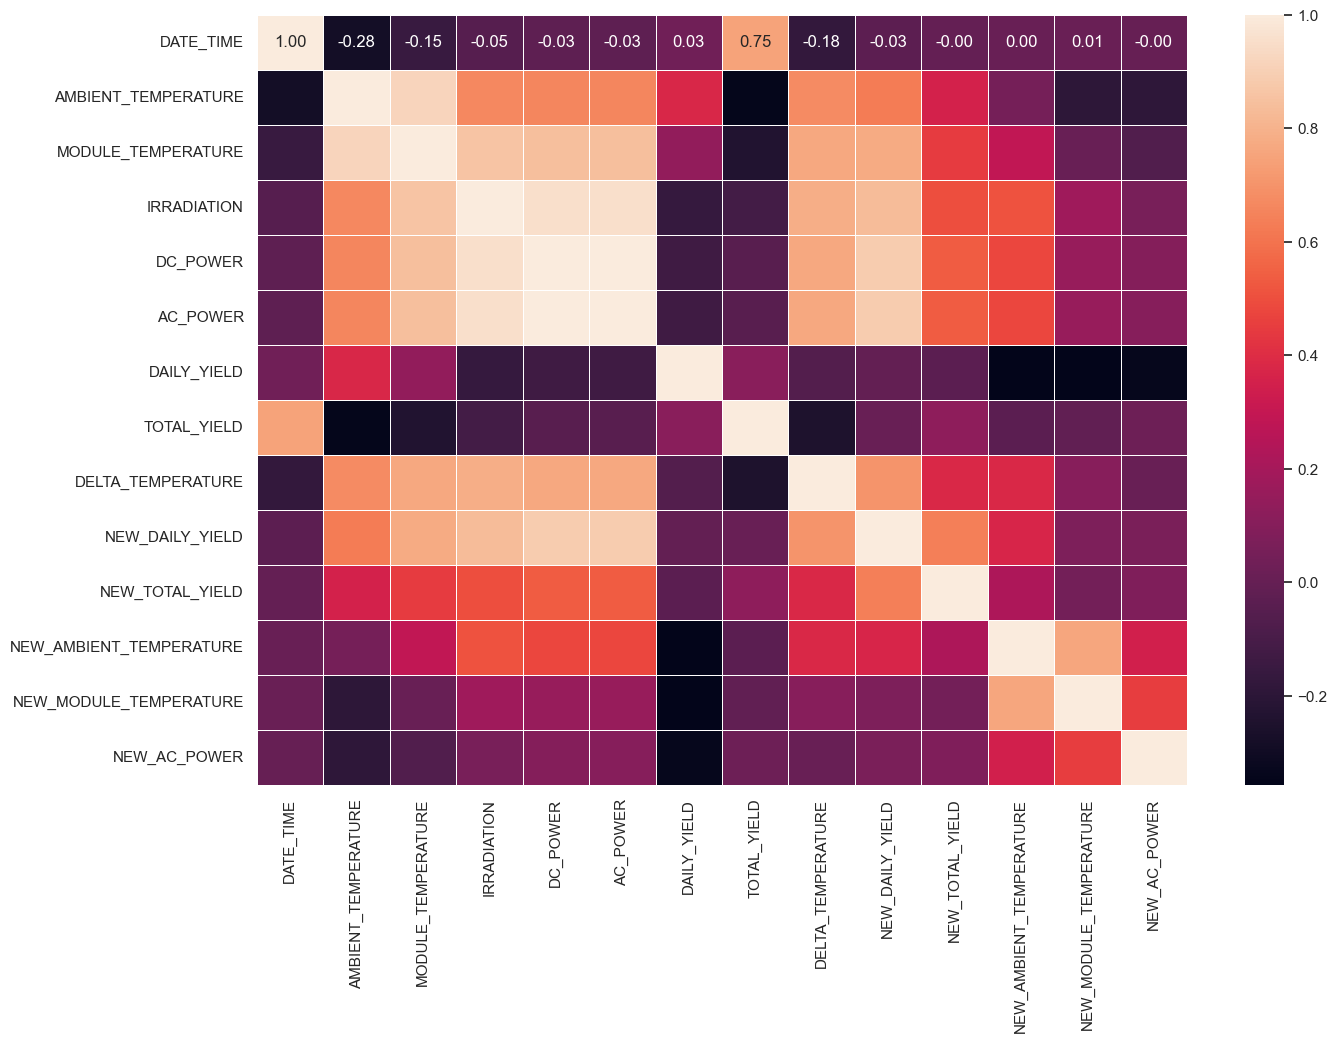

In [131]:
plt.figure(dpi=100, figsize=(15,10))
sns.heatmap(sensorData.corr(method='spearman'), robust=True, annot=True, fmt='0.2f', linewidths=.5, square=False)
plt.show()

In plant II, ``TOTAL_YIELD`` is opposite with all feature except ``DAILY_YIELD``.

Text(0.5, 1.0, 'Regression plot')

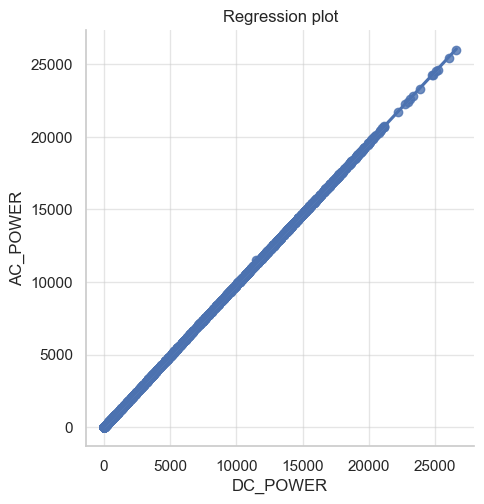

In [132]:
#we plot ac vs dc power
sns.lmplot(x='DC_POWER', y='AC_POWER', data=sensorData)
plt.title('Regression plot')

In plant two, dc power = ac power, Inverter lost 0% of the power.

Text(0.5, 1.0, 'Regression plot')

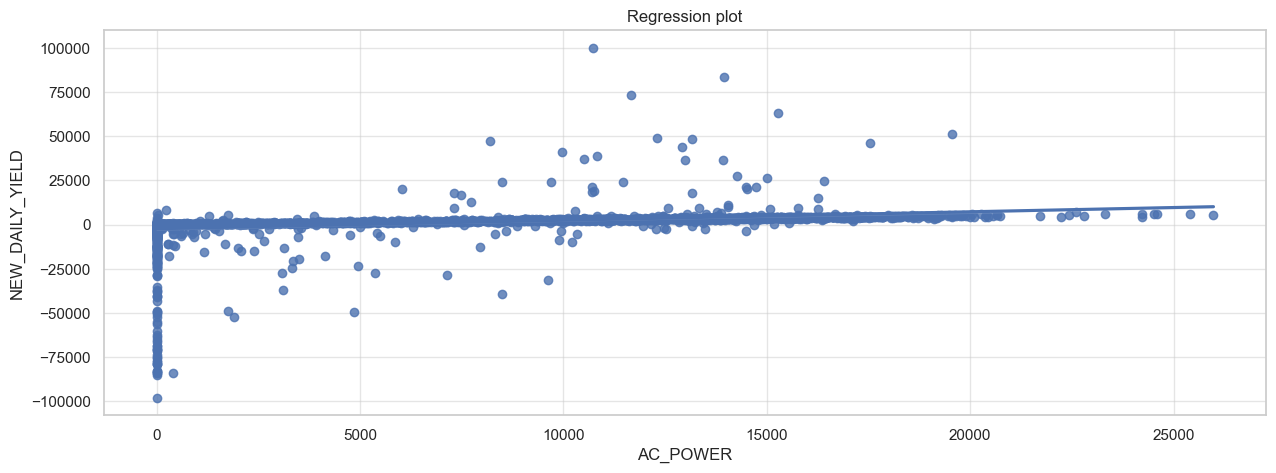

In [133]:
#we plot New DAILY YIELD vs ac power
plt.figure(dpi=(100), figsize=(15,5))
sns.regplot(x='AC_POWER', y='NEW_DAILY_YIELD', data=sensorData)
plt.title('Regression plot')

**We learn**

1. AC_POWER < 5000 KW, the NEW_DAILY_YIELD is negative.
2. AC_POWER between 5000 KW and 12000 KW, NEW_DAILY_YIELD is both positive and negative
3. AC_POWER > 12000 KW is positive.

Text(0.5, 1.0, 'Regression plot')

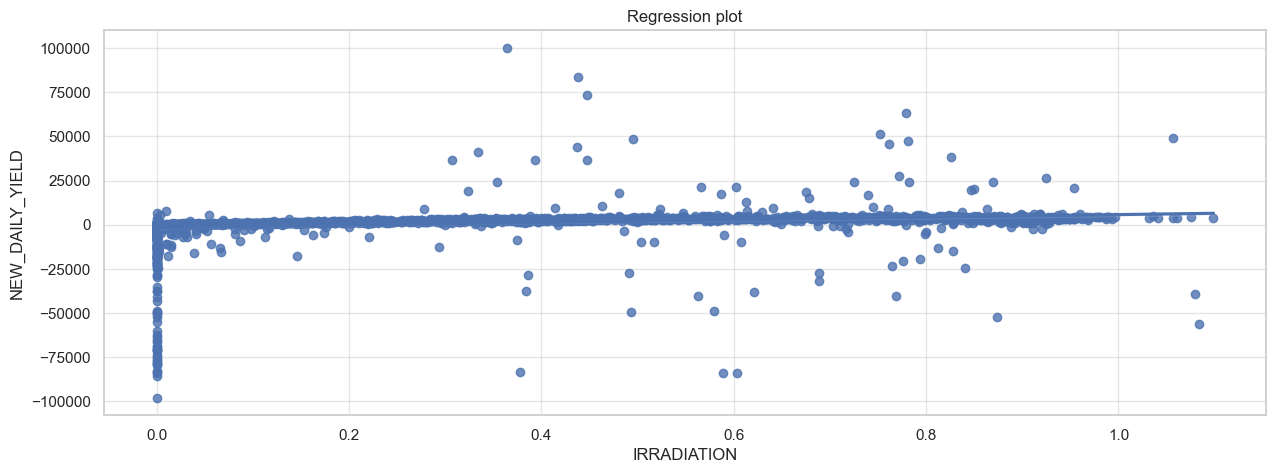

In [134]:
#we plot New DAILY YIELD vs IRRADIATION
plt.figure(dpi=(100), figsize=(15,5))
sns.regplot(x='IRRADIATION', y='NEW_DAILY_YIELD', data=sensorData)
plt.title('Regression plot')

**We learn**

NEW_DAILY_YIELD are positive and negative along the variation of irradiation

Text(0.5, 1.0, 'Regression plot')

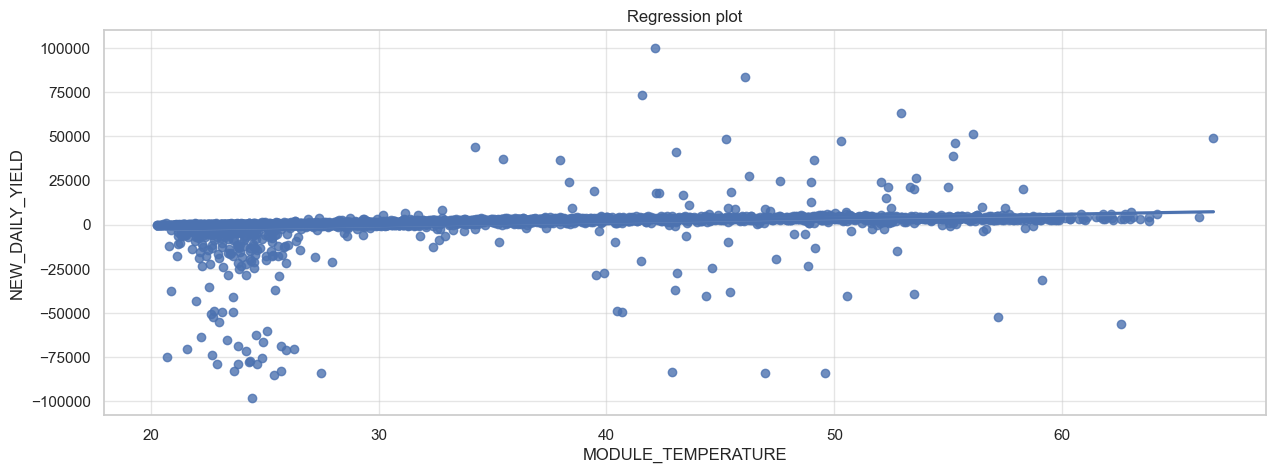

In [135]:
#we plot New DAILY YIELD vs ac power
plt.figure(dpi=(100), figsize=(15,5))
sns.regplot(x='MODULE_TEMPERATURE', y='NEW_DAILY_YIELD', data=sensorData)
plt.title('Regression plot')

**We learn**

for MODULE_TEMPERATURE < 30°C, NEW_DAILY_TEMPERATURE is negative. This means that PV panel product the energy if temperature is around 35°C. 

Text(0.5, 1.0, 'Regression plot')

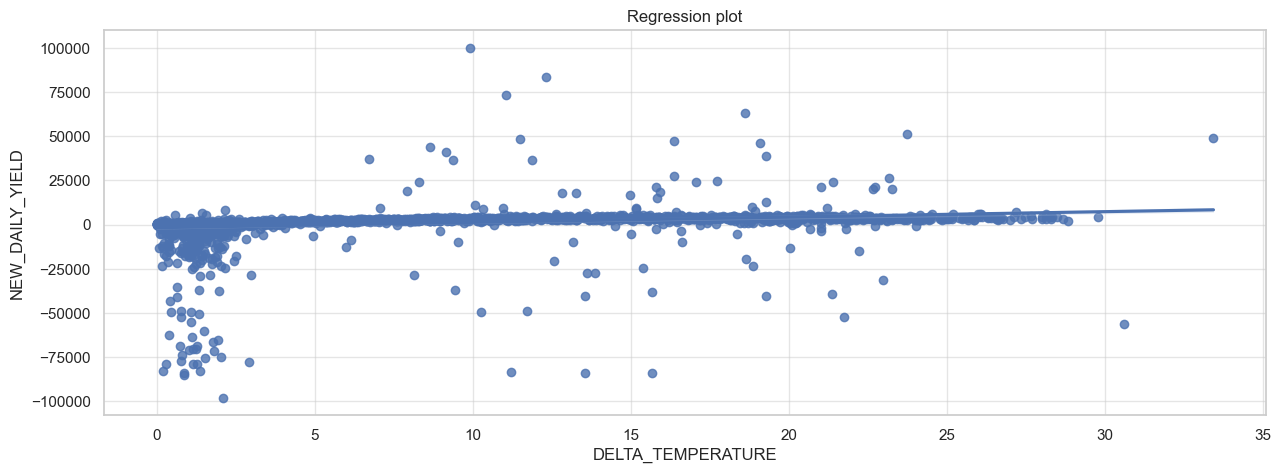

In [136]:
#we plot New DAILY YIELD vs DELTA TEMPERATURE
plt.figure(dpi=(100), figsize=(15,5))
sns.regplot(x='DELTA_TEMPERATURE', y='NEW_DAILY_YIELD', data=sensorData)
plt.title('Regression plot')

**We learn**

NEW_DAILY_YIELD is only negative if DELTA_TEMPERATURE < 5°C. This means that daily yield decrease every 15min if the difference temperature between ambient and module temperature is less than 5°C.

Text(0.5, 1.0, 'Regression plot')

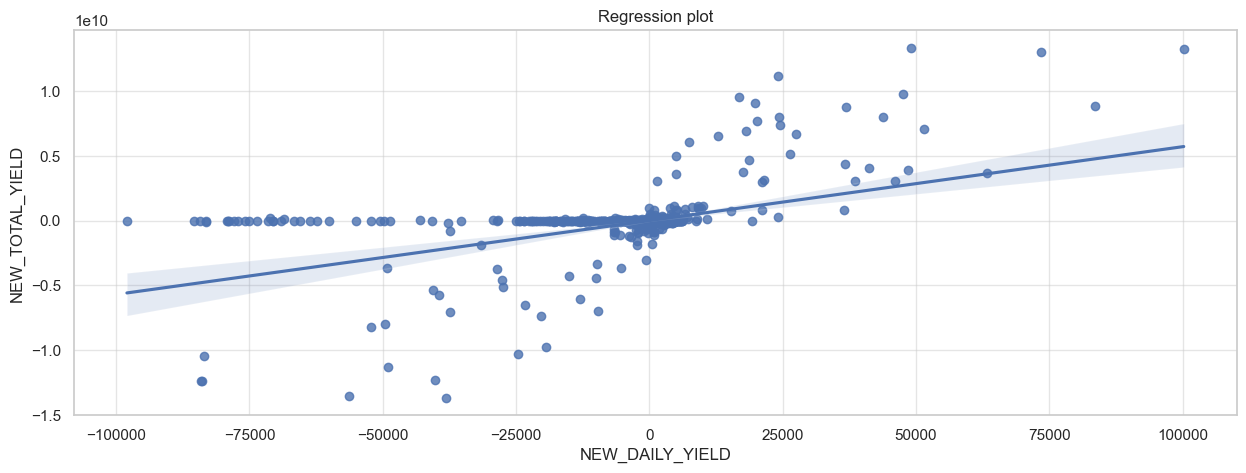

In [137]:
#we plot New TOTAL YIELD vs New daily yield
plt.figure(dpi=(100), figsize=(15,5))
sns.regplot(y='NEW_TOTAL_YIELD', x='NEW_DAILY_YIELD', data=sensorData)
plt.title('Regression plot')

Text(0.5, 1.0, 'Regression plot')

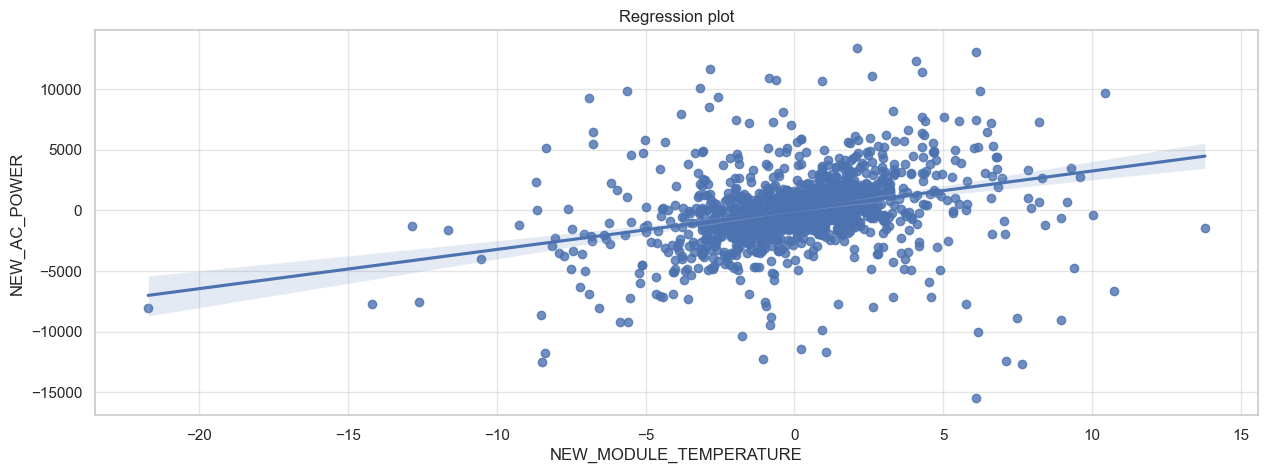

In [138]:
#we plot New TOTAL YIELD vs New daily yield
plt.figure(dpi=(100), figsize=(15,5))
sns.regplot(y='NEW_AC_POWER', x='NEW_MODULE_TEMPERATURE', data=sensorData)
plt.title('Regression plot')

New AC Power is the change of previous and next AC Power produced in the time. We have more AC Power only if New Module Temperature is between -5 and 5. 

**We learn**

1. New daily yield decrease total yield decrease. new daily yield increase, new total yield increase. 
2. new daily yield is zeros, new total yield is zeros

**General Conclusion**

throughout this notebook, we can say that
1. plant I produces 6 times more DC power than plant II. And loses 90% of it when converting to AC power.
2. While Plant II loses nothing when converting DC power to AC power.

3. AC power output is almost the same for both plants.

4. The daily yield is almost the same for the two plants.

5. The gap between The average total yield for plant I and plant II is very large. 

6. Daily yield decrease if delta temperature is less than 5°C.

7. Daily yield decrease for some value of AC power.

END.

**Be free to comment, share and download, give your opinion for this work. Thanks**